# 06 — Machine Learning

**Input:** bảng `public.city_temperature_features` và file `data/processed/feature_metadata.json`, cả hai được bàn giao từ `05_feature_engineering.ipynb`.

**Output chính:** `models/model.pkl` (Pipeline của mô hình tốt nhất, bao gồm cả preprocessing) và `models/model_metadata.json` (ghi lại feature, chỉ số đánh giá, horizon và thời điểm huấn luyện). Notebook 07 và `app/` sẽ nạp hai file này để dự đoán.

**Bài toán:** ước lượng `city_average_temperature` của một thành phố cho thời điểm người dùng chọn trong **1–12 tháng tương lai**, dùng 14 feature số và `country_name` mà Notebook 05 đã chọn, theo đúng thứ tự đã lưu trong `feature_metadata.json`.

> **Khác biệt có chủ đích so với `AGENTS_climate_project.md`:** mục 5.6 của tài liệu đó gợi ý huấn luyện tối thiểu 5 mô hình. Theo yêu cầu cụ thể cho notebook này, chỉ 3 mô hình được huấn luyện đầy đủ: **Linear Regression, Random Forest, XGBoost**. Đây là quyết định phạm vi được xác nhận, không phải thiếu sót.

## 1. Mục tiêu, vai trò và pipeline Machine Learning


### 1.1. Mục tiêu của Notebook

Notebook này trả lời câu hỏi: **với các feature chỉ biết trước tại tháng mục tiêu, mô hình nào dự báo nhiệt độ trung bình kỳ vọng của thành phố tốt nhất trong phạm vi 1–12 tháng tương lai?**

Các việc chính:

1. Đọc đúng bảng đặc trưng và đúng hợp đồng (`feature_metadata.json`) mà Notebook 05 để lại.
2. Kiểm tra tập đầu vào không còn feature lịch sử (`lag`/`rolling`) và xử lý `country_name` bằng one-hot encoding trong Pipeline.
3. Huấn luyện ba mô hình có bản chất khác nhau: một mô hình tuyến tính (Linear Regression) và hai mô hình dạng cây (Random Forest, XGBoost).
4. So sánh ba mô hình với climatology baseline trên **validation**, rồi kiểm tra theo các forecast origin lịch sử với horizon 1–12 tháng.
5. Chọn một mô hình, đánh giá **đúng một lần duy nhất** trên tập **test** và lưu trọn Pipeline cho Notebook 07.

### 1.2. Vai trò của Machine Learning trong dự án

Notebook 04 (EDA) mô tả dữ liệu, Notebook 05 (Feature Engineering) biến mô tả đó thành các feature khả dụng khi dự báo. Notebook 06 là bước biến chúng thành một **hàm ước lượng cụ thể**: đưa vào thành phố và thời điểm tương lai trong phạm vi 12 tháng, trả về nhiệt độ trung bình kỳ vọng.

Đây cũng là notebook duy nhất trong pipeline phải trả lời câu hỏi **đánh đổi**: mô hình đơn giản (Linear Regression) dễ giải thích và triển khai nhưng có thể bỏ lỡ quan hệ phi tuyến; mô hình phức tạp hơn (Random Forest, XGBoost) thường chính xác hơn nhưng nặng hơn và khó diễn giải hơn. Mục VIII sẽ cân nhắc đánh đổi này bằng số liệu thật, không phỏng đoán.

### 1.3. Pipeline

```text
Notebook 05 — Feature Engineering
   ↓ public.city_temperature_features + feature_metadata.json
Notebook 06 — Machine Learning (notebook này)
   ↓ one-hot `country_name` + huấn luyện, so sánh với climatology baseline
   ↓ rolling-origin backtest 1–12 tháng trên validation
   ↓ đánh giá một lần trên test + lưu Pipeline
   ↓ models/model.pkl + models/model_metadata.json
Notebook 07 — Prediction Demo
```

## 2. Chuẩn bị môi trường, dữ liệu và data contract


### 2.1. Nạp các thư viện cần thiết

`pandas`/`numpy` xử lý dữ liệu; `scikit-learn` cung cấp Pipeline, one-hot encoding và hai model đầu; `xgboost` dùng cho model thứ ba. Toàn bộ preprocessing nằm trong Pipeline để khi triển khai không fit lại từ validation hoặc test.


In [2]:
import json
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 170)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5.5)
plt.rcParams['font.size'] = 10

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Thư viện đã sẵn sàng.')

Thư viện đã sẵn sàng.


### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc hoặc từ `notebooks_v1/`/`notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `models/`.

In [3]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và models/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'models').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và models/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
CANDIDATES_DIR = MODELS_DIR / 'candidates'
REPORT_IMAGES_DIR = PROJECT_ROOT / 'reports' / 'images'
for directory in (MODELS_DIR, CANDIDATES_DIR, REPORT_IMAGES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

METADATA_PATH = PROCESSED_DIR / 'feature_metadata.json'

print('Project root :', PROJECT_ROOT)
print('Models dir   :', MODELS_DIR)

Project root : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Models dir   : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\models


### 2.3. Đọc hợp đồng dữ liệu từ Notebook 05

`feature_metadata.json` là hợp đồng giữa Notebook 05 và Notebook 06: nó tách rõ feature số, feature phân loại, phạm vi forecast và thứ tự input. Notebook 06 không tự thêm lag/rolling; nếu tự chọn lại feature, cổng chống leakage và availability của Notebook 05 sẽ mất tác dụng.

#### 2.3.1. Đọc file metadata

Metadata là hợp đồng chính thức do Notebook 05 bàn giao.


In [4]:
if not METADATA_PATH.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {METADATA_PATH}. Notebook 06 bắt buộc phải chạy sau Notebook 05.'
    )

with open(METADATA_PATH, encoding='utf-8') as handle:
    FEATURE_METADATA = json.load(handle)


#### 2.3.2. Khai báo target, feature và split

Các biến được đọc từ metadata thay vì ghi cứng để tránh lệch feature contract.


In [5]:
TARGET_COLUMN = FEATURE_METADATA['target']
NUMERIC_FEATURES = list(FEATURE_METADATA['numeric_feature_names'])
CATEGORICAL_FEATURES = list(FEATURE_METADATA['categorical_feature_names'])
FEATURE_NAMES = list(FEATURE_METADATA['feature_names'])
KEY_COLUMNS = list(FEATURE_METADATA['key_columns'])
FEATURE_TABLE = FEATURE_METADATA['postgres_table']
TRAIN_CUTOFF_YEAR = FEATURE_METADATA['train_cutoff_year']
VALIDATION_START_YEAR = FEATURE_METADATA['validation_start_year']
FEATURE_FIT_CUTOFF_YEAR = FEATURE_METADATA['feature_fit_cutoff_year']
EXPECTED_SPLIT_COUNTS = FEATURE_METADATA['split_counts']
EXPECTED_ROW_COUNT = FEATURE_METADATA['row_count']
FORECAST_HORIZON_MONTHS = int(FEATURE_METADATA['forecast_horizon_months'])
ALLOWED_AVAILABILITY = set(FEATURE_METADATA['deployment_allowed_availability'])


#### 2.3.3. Kiểm tra feature contract

Chỉ `static` và `fit_stat` được phép đi vào model triển khai.


In [6]:
if FEATURE_NAMES != NUMERIC_FEATURES + CATEGORICAL_FEATURES:
    raise RuntimeError('feature_names phải là numeric_feature_names + categorical_feature_names.')
history_features = [
    name for name in NUMERIC_FEATURES
    if FEATURE_METADATA['feature_details'][name]['availability'] not in ALLOWED_AVAILABILITY
]
if history_features:
    raise RuntimeError(f'Notebook 05 còn bàn giao feature không triển khai được: {history_features}')

print(f'Biến mục tiêu       : {TARGET_COLUMN}')
print(f'Feature số          : {len(NUMERIC_FEATURES)}')
print(f'Feature phân loại   : {CATEGORICAL_FEATURES}')
print(f'Tổng đầu vào model  : {len(FEATURE_NAMES)}')
print(f'Forecast horizon    : 1–{FORECAST_HORIZON_MONTHS} tháng')
print(f'Bảng nguồn          : {FEATURE_TABLE}')
print(f'Feature-fit / Train : <= {FEATURE_FIT_CUTOFF_YEAR}')
print(f'Validation          : {VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR}')
print(f'Test                : > {TRAIN_CUTOFF_YEAR}')
print()
print('Feature theo đúng thứ tự đã chốt ở Notebook 05:')
for position, name in enumerate(FEATURE_NAMES, start=1):
    group = FEATURE_METADATA['feature_details'][name]['group']
    availability = FEATURE_METADATA['feature_details'][name]['availability']
    print(f'  {position:>2}. {name:<26} [{group}, availability={availability}]')


Biến mục tiêu       : city_average_temperature
Feature số          : 14
Feature phân loại   : ['country_name']
Tổng đầu vào model  : 15
Forecast horizon    : 1–12 tháng
Bảng nguồn          : public.city_temperature_features
Feature-fit / Train : <= 1983
Validation          : 1984–1993
Test                : > 1993

Feature theo đúng thứ tự đã chốt ở Notebook 05:
   1. month_sin                  [Thời gian, availability=static]
   2. month_cos                  [Thời gian, availability=static]
   3. climatic_month_sin         [Thời gian, availability=static]
   4. climatic_month_cos         [Thời gian, availability=static]
   5. years_since_start          [Thời gian, availability=static]
   6. latitude                   [Địa lý, availability=static]
   7. abs_latitude               [Địa lý, availability=static]
   8. hemisphere_north           [Địa lý, availability=static]
   9. longitude                  [Địa lý, availability=static]
  10. abslat_x_month_sin         [Tương tác, availabil

Cột `availability` cho biết điều kiện dùng lúc dự báo thật. Contract mới chỉ cho phép `static` (biết trước từ vị trí/ngày) và `fit_stat` (climatology đã học). Notebook 07/app không được thêm trở lại feature `history` vì chúng không tồn tại cho tháng tương lai người dùng chọn.

### 2.4. Kết nối PostgreSQL bắt buộc

Notebook 06 chỉ đọc dữ liệu từ `public.city_temperature_features` — bảng chính thức mà Notebook 05 đã nạp và kiểm tra row count. Không có nhánh fallback CSV, để tránh vô tình huấn luyện trên một phiên bản dữ liệu khác với phiên bản đã qua kiểm tra rò rỉ.

#### 2.4.1. Đọc cấu hình an toàn

Nạp `.env` và kiểm tra đủ biến kết nối; mật khẩu không xuất hiện trong notebook.


In [7]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(f'Không tìm thấy {ENV_PATH}. Notebook 06 chỉ đọc dữ liệu từ PostgreSQL.')

import os

from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise ValueError(f'.env thiếu các biến: {missing_env}')


#### 2.4.2. Tạo engine đọc dữ liệu

Engine chỉ phục vụ đọc bảng feature vào DataFrame.


In [8]:
DB_ENGINE = create_engine(
    URL.create(
        drivername='postgresql+psycopg2',
        username=os.environ['DB_USER'],
        password=os.environ['DB_PASSWORD'],
        host=os.environ['DB_HOST'],
        port=int(os.environ['DB_PORT']),
        database=os.environ['DB_NAME'],
    ),
    pool_pre_ping=True,
    connect_args={'connect_timeout': 10},
)


#### 2.4.3. Xác nhận bảng nguồn

Notebook dừng nếu `public.city_temperature_features` chưa được tạo ở Notebook 05.


In [9]:
table_name = FEATURE_TABLE.split('.')[-1]
with DB_ENGINE.connect() as connection:
    check = connection.execute(
        text(f"SELECT to_regclass('{FEATURE_TABLE}') IS NOT NULL AS table_exists")
    ).scalar()
if not check:
    raise RuntimeError(f'{FEATURE_TABLE} chưa tồn tại. Hãy chạy Notebook 05 trước.')
print(f'PASS: kết nối PostgreSQL thành công, {FEATURE_TABLE} tồn tại.')


PASS: kết nối PostgreSQL thành công, public.city_temperature_features tồn tại.


### 2.5. Đọc bảng đặc trưng

Chỉ đọc khóa nghiệp vụ, target, 14 feature số, `country_name` và hai nhãn split. `country_name` đã nằm trong khóa nên chỉ xuất hiện một lần trong truy vấn; one-hot chỉ diễn ra sau khi tách train/validation/test.

In [10]:
columns_to_read = list(KEY_COLUMNS)
for name in [TARGET_COLUMN] + FEATURE_NAMES + ['data_split', 'is_train_period']:
    if name not in columns_to_read:
        columns_to_read.append(name)

query = text(f"SELECT {', '.join(columns_to_read)} FROM {FEATURE_TABLE}")

start_time = time.time()
with DB_ENGINE.connect() as connection:
    df = pd.read_sql_query(query, connection)
print(f'Đã đọc {len(df):,} dòng x {df.shape[1]} cột trong {time.time() - start_time:,.1f} giây.')

Đã đọc 5,579,085 dòng x 22 cột trong 81.1 giây.


### 2.6. Kiểm tra kích thước dữ liệu

In [11]:
if len(df) != EXPECTED_ROW_COUNT:
    raise RuntimeError(
        f'Số dòng đọc được ({len(df):,}) khác số dòng kỳ vọng trong metadata ({EXPECTED_ROW_COUNT:,}).'
    )
print(f'PASS: số dòng khớp metadata ({len(df):,} dòng, {df.shape[1]} cột).')

split_counts_actual = df['data_split'].value_counts().to_dict()
for split_name, expected_count in EXPECTED_SPLIT_COUNTS.items():
    actual_count = split_counts_actual.get(split_name, 0)
    status = 'PASS' if actual_count == expected_count else 'FAIL'
    print(f'{status}: {split_name:<10} kỳ vọng {expected_count:>9,} · thực tế {actual_count:>9,}')

PASS: số dòng khớp metadata (5,579,085 dòng, 22 cột).
PASS: train      kỳ vọng 4,468,327 · thực tế 4,468,327
PASS: test       kỳ vọng   736,478 · thực tế   736,478
PASS: validation kỳ vọng   374,280 · thực tế   374,280


### 2.7. Kiểm tra kiểu dữ liệu

`observation_date` được ép về kiểu ngày; `city_name`/`country_name`/`data_split` dùng `category` vì số giá trị duy nhất nhỏ; các cột số dùng `float32` để giảm bộ nhớ mà không mất thông tin (dữ liệu gốc chỉ có 3–4 chữ số thập phân).

In [12]:
df['observation_date'] = pd.to_datetime(df['observation_date'])
for column in ('city_name', 'country_name', 'data_split'):
    df[column] = df[column].astype('category')
df['year'] = df['year'].astype('int16')
df['month'] = df['month'].astype('int8')
df['is_train_period'] = df['is_train_period'].astype('int8')
if df['hemisphere_north'].dtype != 'int8':
    df['hemisphere_north'] = df['hemisphere_north'].astype('bool').astype('int8')

numeric_columns = [TARGET_COLUMN] + [
    name for name in NUMERIC_FEATURES if name != 'hemisphere_north'
]
for column in numeric_columns:
    df[column] = df[column].astype('float32')

display(df.dtypes.to_frame('dtype'))
print(f'Bộ nhớ hiện tại: {df.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB')

,dtype
observation_date,datetime64[s]
city_name,category
country_name,category
latitude,float32
longitude,float32
year,int16
month,int8
city_average_temperature,float32
month_sin,float32
month_cos,float32


Bộ nhớ hiện tại: 388.5 MB


### 2.8. Xác định Feature và Target

In [13]:
X_ALL_COLUMNS = FEATURE_NAMES
Y_COLUMN = TARGET_COLUMN

print(f'Target (y)  : {Y_COLUMN}')
print(f'Feature số (X)       : {NUMERIC_FEATURES}')
print(f'Feature phân loại (X): {CATEGORICAL_FEATURES} → one-hot trong Pipeline')
display(df[[Y_COLUMN] + NUMERIC_FEATURES].describe().T)
display(df[CATEGORICAL_FEATURES].describe().T)

Target (y)  : city_average_temperature
Feature số (X)       : ['month_sin', 'month_cos', 'climatic_month_sin', 'climatic_month_cos', 'years_since_start', 'latitude', 'abs_latitude', 'hemisphere_north', 'longitude', 'abslat_x_month_sin', 'abslat_x_month_cos', 'loc_month_climatology', 'loc_mean_temperature', 'loc_temperature_std']
Feature phân loại (X): ['country_name'] → one-hot trong Pipeline


,count,mean,std,min,25%,50%,75%,max
city_average_temperature,"5,579,085.0000",17.5021,10.1935,-42.7040,11.6060,19.8260,25.6370,39.1560
month_sin,"5,579,085.0000",0.0013,0.7071,-1.0000,-0.5000,0.0000,0.8660,1.0000
month_cos,"5,579,085.0000",-0.0013,0.7071,-1.0000,-0.8660,0.0000,0.5000,1.0000
climatic_month_sin,"5,579,085.0000",0.0008,0.7071,-1.0000,-0.5000,0.0000,0.8660,1.0000
climatic_month_cos,"5,579,085.0000",-0.0008,0.7071,-1.0000,-0.8660,0.0000,0.5000,1.0000
years_since_start,"5,579,085.0000",75.5843,43.1309,0.0000,38.0000,76.0000,113.0000,150.0000
latitude,"5,579,085.0000",23.4698,23.1319,-52.2400,10.4500,28.1300,39.3800,69.9200
abs_latitude,"5,579,085.0000",29.4948,14.6960,0.8000,20.0900,29.7400,39.3800,69.9200
hemisphere_north,"5,579,085.0000",0.8311,0.3747,0.0000,1.0000,1.0000,1.0000,1.0000
longitude,"5,579,085.0000",34.9669,76.7631,-151.1300,-7.5400,43.6400,106.2200,159.5500


,count,unique,top,freq
country_name,5579085,50,India,693711


Bảng thống kê xác nhận target hợp lý, các feature chu kỳ nằm trong [-1, 1] và `hemisphere_north` chỉ nhận 0/1. `country_name` là biến phân loại nên chỉ kiểm tra số nhóm; không được đổi nó thành mã số thứ tự vì sẽ tạo quan hệ giả giữa các quốc gia.

## 3. Chuẩn bị dữ liệu cho huấn luyện


### 3.1. Phát hiện các cột có vấn đề

Tập mới có một biến phân loại là `country_name`; biến này phải được one-hot **bên trong Pipeline** để encoder chỉ học các nhóm từ train. Khác với pipeline cũ, tập triển khai không chứa lag/rolling nên không còn thiếu dữ liệu do đầu chuỗi. Bất kỳ `NaN` nào trong target hoặc feature future-known đều là lỗi data contract và phải dừng notebook.

In [14]:
missing_report = (
    df[X_ALL_COLUMNS + [Y_COLUMN]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame('Thiếu (%)')
)
missing_report = missing_report[missing_report['Thiếu (%)'] > 0]
if missing_report.empty:
    print('Không có cột nào thiếu giá trị.')
else:
    display(missing_report)

rows_with_any_missing = df[X_ALL_COLUMNS + [Y_COLUMN]].isna().any(axis=1)
print(
    f'Số dòng thiếu ít nhất một giá trị: {int(rows_with_any_missing.sum()):,} '
    f'({rows_with_any_missing.mean():.2%} tổng dữ liệu).'
)

Không có cột nào thiếu giá trị.
Số dòng thiếu ít nhất một giá trị: 0 (0.00% tổng dữ liệu).


### 3.2. Xử lý các cột có vấn đề

Notebook **không drop dòng để che lỗi**. Nếu feature future-known hoặc target thiếu, quá trình dừng để nhóm kiểm tra lại Notebook 05. `SimpleImputer` được đặt trong Pipeline như lớp phòng vệ cho dữ liệu ứng dụng mới, nhưng không được fit trên validation/test và không thay thế việc kiểm tra data contract.

In [15]:
required_columns = X_ALL_COLUMNS + [Y_COLUMN]
missing_rows = df[required_columns].isna().any(axis=1)
if missing_rows.any():
    missing_by_column = df.loc[missing_rows, required_columns].isna().sum()
    raise RuntimeError(
        'Data contract mới không cho phép missing trong feature/target. '
        + str(missing_by_column[missing_by_column.gt(0)].to_dict())
    )

df_clean = df.copy()
print(f'PASS: giữ nguyên {len(df_clean):,} dòng; không có lag/rolling NaN để loại.')

PASS: giữ nguyên 5,579,085 dòng; không có lag/rolling NaN để loại.


### 3.3. Chia Train / Validation / Test

Notebook 06 **không chia lại ngẫu nhiên**. Đây là dữ liệu theo thời gian: nếu chia ngẫu nhiên, thời điểm sau có thể lọt vào train trong khi thời điểm trước nằm ở test, làm sai ý nghĩa dự báo tương lai.

Notebook 05 đã chia sẵn theo thời gian và ghi vào cột `data_split`:

- **`train`** (≤ 1983): dùng để **huấn luyện** cả ba mô hình.
- **`validation`** (1984–1993): dùng để **so sánh và chọn** mô hình tốt nhất (Mục VII–VIII). Không dùng để huấn luyện.
- **`test`** (> 1993): giữ nguyên, chỉ mở ra **đúng một lần** ở Mục VIII để báo cáo số liệu cuối cùng.

In [16]:
train_df = df_clean.loc[df_clean['data_split'] == 'train'].copy()
validation_df = df_clean.loc[df_clean['data_split'] == 'validation'].copy()
test_df = df_clean.loc[df_clean['data_split'] == 'test'].copy()

X_train, y_train = train_df[X_ALL_COLUMNS], train_df[Y_COLUMN]
X_validation, y_validation = validation_df[X_ALL_COLUMNS], validation_df[Y_COLUMN]
X_test, y_test = test_df[X_ALL_COLUMNS], test_df[Y_COLUMN]

print(f'Train      : {len(train_df):>9,} dòng (≤ {FEATURE_FIT_CUTOFF_YEAR})')
print(f'Validation : {len(validation_df):>9,} dòng ({VALIDATION_START_YEAR}–{TRAIN_CUTOFF_YEAR})')
print(f'Test       : {len(test_df):>9,} dòng (> {TRAIN_CUTOFF_YEAR}, khóa tới Mục VIII)')

if train_df.empty or validation_df.empty or test_df.empty:
    raise RuntimeError('Một trong ba tập train/validation/test rỗng sau khi làm sạch.')

Train      : 4,468,327 dòng (≤ 1983)
Validation :   374,280 dòng (1984–1993)
Test       :   736,478 dòng (> 1993, khóa tới Mục VIII)


### 3.4. Hàm đánh giá dùng chung

Ba chỉ số được dùng thống nhất cho mọi model:

| Chỉ số | Cách đọc |
|---|---|
| MAE | Sai số tuyệt đối trung bình, đơn vị °C |
| RMSE | Phạt mạnh hơn với sai số lớn, dùng để chọn model trên validation |
| R² | Tỷ lệ biến thiên target được mô hình giải thích |

RMSE validation là tiêu chí chính. Chỉ số train chỉ dùng phát hiện dấu hiệu overfitting; test được khóa đến Mục 8.4.


#### 3.4.1. Hàm tính metric

Một hàm metric dùng chung giúp so sánh ba model trên cùng công thức.


In [17]:
MODEL_RESULTS = []


def compute_metrics(y_true, y_pred) -> dict:
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


#### 3.4.2. Tạo preprocessing

Numeric được impute; `country_name` được one-hot bên trong Pipeline. Chỉ `fit()` trên train mới học các tham số này.


In [18]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    """Tạo preprocessing chỉ được fit khi Pipeline.fit() nhận tập train."""
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer(
        transformers=[
            ('numeric', Pipeline(numeric_steps), NUMERIC_FEATURES),
            (
                'country',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


#### 3.4.3. Tạo Pipeline và tên feature sau biến đổi

Pipeline đóng gói preprocessing với estimator, giúp train và triển khai dùng cùng xử lý.


In [19]:
def make_model_pipeline(estimator, scale_numeric: bool) -> Pipeline:
    return Pipeline([
        ('preprocessor', make_preprocessor(scale_numeric)),
        ('model', estimator),
    ])


def transformed_feature_names(model_pipeline: Pipeline) -> list[str]:
    return list(model_pipeline.named_steps['preprocessor'].get_feature_names_out())


#### 3.4.4. Ghi nhận kết quả model

Mỗi model trả về metric train, validation, thời gian và dung lượng artifact.


In [20]:
def log_result(name, y_train_true, y_train_pred, y_val_true, y_val_pred, fit_seconds, file_path):
    train_metrics = compute_metrics(y_train_true, y_train_pred)
    validation_metrics = compute_metrics(y_val_true, y_val_pred)
    record = {
        'Mô hình': name,
        'MAE (train)': train_metrics['MAE'],
        'RMSE (train)': train_metrics['RMSE'],
        'R2 (train)': train_metrics['R2'],
        'MAE (validation)': validation_metrics['MAE'],
        'RMSE (validation)': validation_metrics['RMSE'],
        'R2 (validation)': validation_metrics['R2'],
        'Thời gian huấn luyện (giây)': fit_seconds,
        'Dung lượng file (MB)': file_path.stat().st_size / 1024 ** 2 if file_path else float('nan'),
    }
    MODEL_RESULTS.append(record)
    return record


#### 3.4.5. Tạo climatology baseline

Baseline dùng `loc_month_climatology`; nó là mốc bắt buộc để biết model cải thiện bao nhiêu.


In [21]:
baseline_validation_pred = validation_df['loc_month_climatology'].to_numpy()
baseline_validation_metrics = compute_metrics(y_validation, baseline_validation_pred)
print('Climatology baseline trên validation:')
for metric_name, value in baseline_validation_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')
print('Đã định nghĩa metrics, one-hot preprocessing và Pipeline dùng chung.')


Climatology baseline trên validation:
  MAE  : 0.9734
  RMSE : 1.3664
  R2   : 0.9816
Đã định nghĩa metrics, one-hot preprocessing và Pipeline dùng chung.


## 4. Mô hình Linear Regression


### 4.1. Giới thiệu Linear Regression

Linear Regression tìm một **tổ hợp cộng tuyến tính** của feature số và các cột one-hot quốc gia. Vì `years_since_start` là biến liên tục, đây cũng là mô hình phù hợp nhất để kiểm tra khả năng ngoại suy xu hướng ra ngoài khoảng năm đã học.

Ưu điểm: huấn luyện cực nhanh, hệ số dễ diễn giải (mỗi đặc trưng đóng góp bao nhiêu độ C). Hạn chế: chỉ học được quan hệ **cộng tuyến tính**, trong khi Notebook 05 đã chỉ ra một phần tín hiệu khí hậu mang bản chất **nhân** (biên độ mùa vụ nhân với vĩ độ) — Mục 6.2 của Notebook 05 đo được phần tín hiệu phi tuyến này bằng `η² − r²`. Đây là điều cần theo dõi khi so sánh với hai mô hình dạng cây ở Mục V–VI.

### 4.2. Lựa chọn Feature đầu vào

Dùng toàn bộ feature trong metadata: 14 feature số và `country_name`. Ba mô hình nhận cùng input; Pipeline biến đổi `country_name` thành one-hot sau khi fit trên train.

In [22]:
LR_FEATURES = list(X_ALL_COLUMNS)
linear_pipeline = make_model_pipeline(LinearRegression(), scale_numeric=True)
print(f'Linear Regression dùng {len(NUMERIC_FEATURES)} feature số + {CATEGORICAL_FEATURES}.')

Linear Regression dùng 14 feature số + ['country_name'].


### 4.3. Chuẩn hóa dữ liệu (StandardScaler)

Feature số có thang đo khác nhau nên Linear Regression chuẩn hóa chúng. `country_name` được one-hot; cột one-hot không cần chuẩn hóa.

`StandardScaler`, `OneHotEncoder` và imputer đều nằm trong Pipeline nên chỉ được fit trên train. Lưu trọn Pipeline giúp ứng dụng không thể vô tình áp dụng preprocessing khác Notebook 06.

In [23]:
print('StandardScaler (numeric) và OneHotEncoder (country) nằm trong linear_pipeline.')
print('Pipeline sẽ chỉ fit preprocessing trên X_train khi huấn luyện ở cell tiếp theo.')

StandardScaler (numeric) và OneHotEncoder (country) nằm trong linear_pipeline.
Pipeline sẽ chỉ fit preprocessing trên X_train khi huấn luyện ở cell tiếp theo.


### 4.4. Huấn luyện mô hình Linear Regression

In [24]:
start_time = time.time()
linear_pipeline.fit(X_train[LR_FEATURES], y_train)
linear_fit_seconds = time.time() - start_time
linear_model = linear_pipeline.named_steps['model']

print(f'Đã huấn luyện Linear Regression trong {linear_fit_seconds:.2f} giây.')

Đã huấn luyện Linear Regression trong 19.21 giây.


### 4.5. Đánh giá mô hình Linear Regression

In [25]:
linear_train_pred = linear_pipeline.predict(X_train[LR_FEATURES])
linear_validation_pred = linear_pipeline.predict(X_validation[LR_FEATURES])

linear_val_metrics = compute_metrics(y_validation, linear_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in linear_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.8699
  RMSE : 1.2787
  R2   : 0.9839


### 4.6. Dự đoán trên tập validation

#### 4.6.1. Chuẩn bị mẫu biểu đồ validation

Chỉ lấy tối đa 20.000 điểm để biểu đồ rõ và không tốn bộ nhớ.


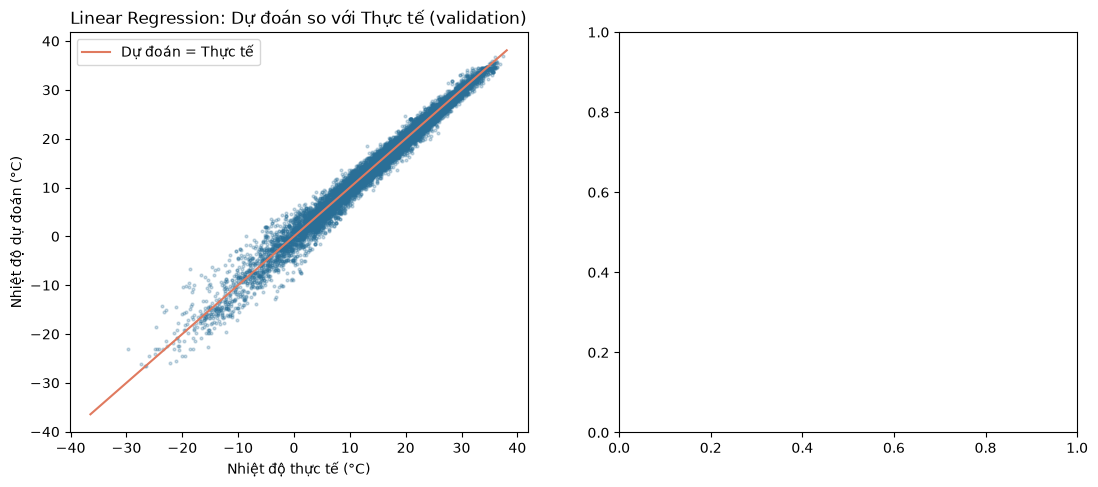

In [26]:
PLOT_SAMPLE_SIZE = 20_000
plot_rng = np.random.default_rng(RANDOM_SEED)
plot_positions = plot_rng.choice(len(y_validation), size=min(PLOT_SAMPLE_SIZE, len(y_validation)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

axes[0].scatter(
    y_validation.to_numpy()[plot_positions], linear_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), linear_validation_pred.min())
value_max = max(y_validation.max(), linear_validation_pred.max())
axes[0].plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
axes[0].set_xlabel('Nhiệt độ thực tế (°C)')
axes[0].set_ylabel('Nhiệt độ dự đoán (°C)')
axes[0].set_title('Linear Regression: Dự đoán so với Thực tế (validation)')
axes[0].legend()


#### 4.6.2. Phân bố sai số và lưu hình

Biểu đồ so sánh dự đoán–thực tế và histogram residual được lưu để dùng trong báo cáo.


In [27]:
residuals = y_validation.to_numpy() - linear_validation_pred
axes[1].hist(residuals, bins=80, color='#2a6f97')
axes[1].axvline(0, color='#e07a5f', linewidth=1.5)
axes[1].set_xlabel('Sai số dự đoán (°C) — thực tế trừ dự đoán')
axes[1].set_title('Phân bố sai số (residual)')

plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '10_linear_regression_actual_vs_predicted.png', dpi=110)
plt.show()

print(f'Sai số trung bình (bias): {residuals.mean():+.4f} °C — gần 0 nghĩa là mô hình không thiên lệch hệ thống.')


<Figure size 1100x550 with 0 Axes>

Sai số trung bình (bias): +0.0711 °C — gần 0 nghĩa là mô hình không thiên lệch hệ thống.


#### Nhận xét biểu đồ validation

Điểm càng gần đường chéo thì dự đoán càng sát giá trị thực tế. Histogram residual tập trung quanh 0 và bias gần 0 cho thấy không có thiên lệch hệ thống rõ rệt; các điểm xa đường chéo vẫn là các tháng khó dự báo hơn.


### 4.7. Xem hệ số hồi quy


,Hệ số (sau Pipeline)
loc_month_climatology,10.1321
years_since_start,0.2200
country_name_Peru,-0.0587
country_name_Tanzania,-0.0461
country_name_Mozambique,-0.0415
...,...
country_name_Sri Lanka,0.0013
month_cos,-0.0013
climatic_month_cos,0.0011
month_sin,-0.0004


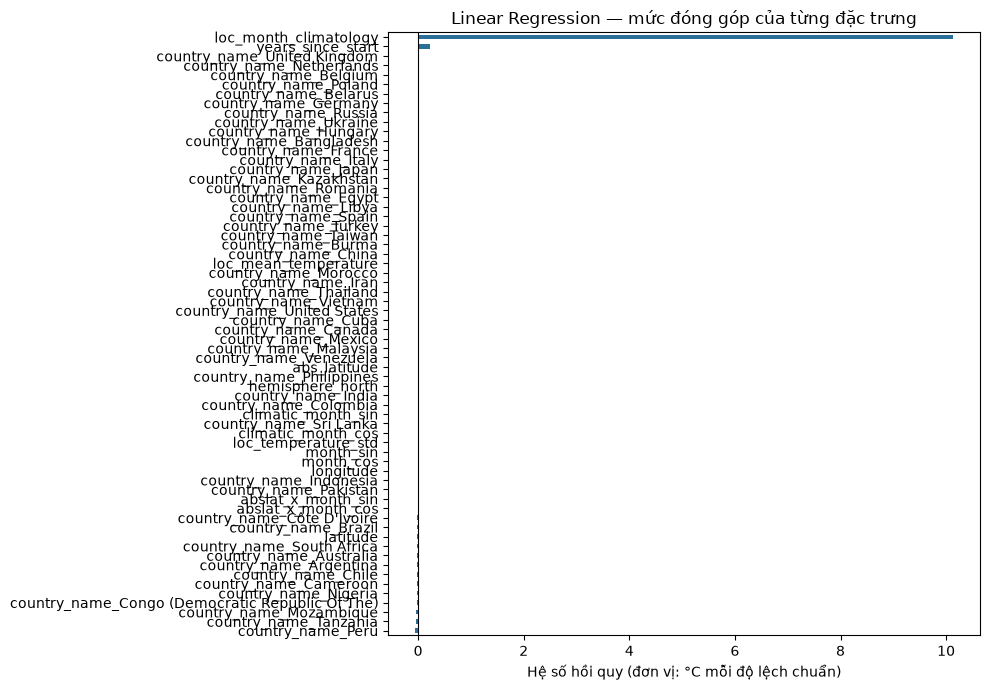

Hệ số chặn (intercept): 17.3242 °C


In [28]:
linear_transformed_features = transformed_feature_names(linear_pipeline)
coefficient_table = (
    pd.Series(linear_model.coef_, index=linear_transformed_features, name='Hệ số (sau Pipeline)')
    .sort_values(key=np.abs, ascending=False)
)
display(coefficient_table.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
coefficient_table.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số hồi quy (đơn vị: °C mỗi độ lệch chuẩn)')
ax.set_title('Linear Regression — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '11_linear_regression_coefficients.png', dpi=110)
plt.show()

print(f'Hệ số chặn (intercept): {linear_model.intercept_:.4f} °C')

Hệ số được tính sau StandardScaler và one-hot encoding. Dấu/hệ số dùng để diễn giải xu hướng trong mô hình tuyến tính, không chứng minh quan hệ nhân quả giữa feature và nhiệt độ.


In [29]:
LINEAR_MODEL_PATH = CANDIDATES_DIR / 'linear_regression_pipeline.pkl'

joblib.dump(linear_pipeline, LINEAR_MODEL_PATH)

log_result(
    'Linear Regression', y_train, linear_train_pred, y_validation, linear_validation_pred,
    linear_fit_seconds, LINEAR_MODEL_PATH,
)
print(f'Đã lưu trọn Pipeline: {LINEAR_MODEL_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu trọn Pipeline: linear_regression_pipeline.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8325,1.2198,0.9858,0.8699,1.2787,0.9839,19.2116,0.0061


## 5. Mô hình Random Forest


### 5.1. Giới thiệu Random Forest

Random Forest huấn luyện **nhiều cây quyết định** trên các mẫu dữ liệu và các tập con đặc trưng khác nhau (lấy ngẫu nhiên có hoàn lại), rồi lấy **trung bình dự đoán** của toàn bộ các cây. Mỗi cây riêng lẻ dễ học vẹt (overfit) dữ liệu, nhưng trung bình của nhiều cây "khác góc nhìn" thường ổn định và chính xác hơn một cây đơn hoặc một đường thẳng.

Khác với Linear Regression, cây quyết định chia dữ liệu bằng các **ngưỡng** (ví dụ: `abs_latitude > 35`), nên tự nhiên học được quan hệ phi tuyến và quan hệ dạng nhân (ví dụ biên độ mùa vụ tăng theo vĩ độ) mà không cần tạo thêm đặc trưng tương tác thủ công — dù Notebook 05 đã tạo sẵn `abslat_x_month_sin`/`abslat_x_month_cos` để hỗ trợ cả hai loại mô hình.

### 5.2. Lựa chọn Feature đầu vào cho Random Forest

Random Forest nhận cùng 14 feature số và `country_name`. Numeric không cần scale cho cây, nhưng `country_name` vẫn phải one-hot trong Pipeline vì cây không nhận chuỗi trực tiếp.

In [30]:
RF_FEATURES = list(X_ALL_COLUMNS)
forest_pipeline = make_model_pipeline(
    RandomForestRegressor(
        n_estimators=100, max_depth=18, min_samples_leaf=5, max_features=0.6,
        n_jobs=-1, random_state=RANDOM_SEED,
    ),
    scale_numeric=False,
)
print(f'Random Forest dùng {len(NUMERIC_FEATURES)} feature số + one-hot country.')

Random Forest dùng 14 feature số + one-hot country.


### 5.3. Huấn luyện mô hình Random Forest

Số cây (`n_estimators=100`) và độ sâu tối đa (`max_depth=18`) được chọn để cân bằng giữa độ chính xác và thời gian huấn luyện trên toàn bộ ~4,47 triệu dòng train — độ sâu quá lớn dễ học vẹt, số cây quá ít làm dự đoán không ổn định. `min_samples_leaf=5` tránh các lá chỉ chứa vài điểm nhiễu. `n_jobs=-1` dùng toàn bộ nhân CPU sẵn có.

In [31]:
start_time = time.time()
forest_pipeline.fit(X_train[RF_FEATURES], y_train)
forest_fit_seconds = time.time() - start_time
forest_model = forest_pipeline.named_steps['model']

print(f'Đã huấn luyện Random Forest ({forest_model.n_estimators} cây) trong {forest_fit_seconds:,.1f} giây.')

Đã huấn luyện Random Forest (100 cây) trong 482.7 giây.


### 5.4. Đánh giá mô hình Random Forest

In [32]:
forest_train_pred = forest_pipeline.predict(X_train[RF_FEATURES])
forest_validation_pred = forest_pipeline.predict(X_validation[RF_FEATURES])

forest_val_metrics = compute_metrics(y_validation, forest_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in forest_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

forest_train_metrics = compute_metrics(y_train, forest_train_pred)
print('\nĐánh giá trên chính tập train (để so sánh mức độ overfit ở Mục VIII):')
for metric_name, value in forest_train_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.9165
  RMSE : 1.3493
  R2   : 0.9820

Đánh giá trên chính tập train (để so sánh mức độ overfit ở Mục VIII):
  MAE  : 0.3781
  RMSE : 0.6213
  R2   : 0.9963


### 5.5. Xem Feature Importance của Random Forest

Feature importance của Random Forest đo mức giảm sai số trung bình mà mỗi đặc trưng đóng góp khi được dùng để chia nhánh, cộng dồn qua toàn bộ cây. Khác với hệ số hồi quy ở Mục 4.7, importance luôn không âm và không cho biết chiều tác động (tăng hay giảm nhiệt độ).

,Importance
loc_month_climatology,0.7512
loc_mean_temperature,0.1265
abslat_x_month_cos,0.0327
abs_latitude,0.0297
loc_temperature_std,0.0153
...,...
country_name_Sri Lanka,0.0000
country_name_Côte D'Ivoire,0.0000
country_name_Congo (Democratic Republic Of The),0.0000
country_name_Tanzania,0.0000


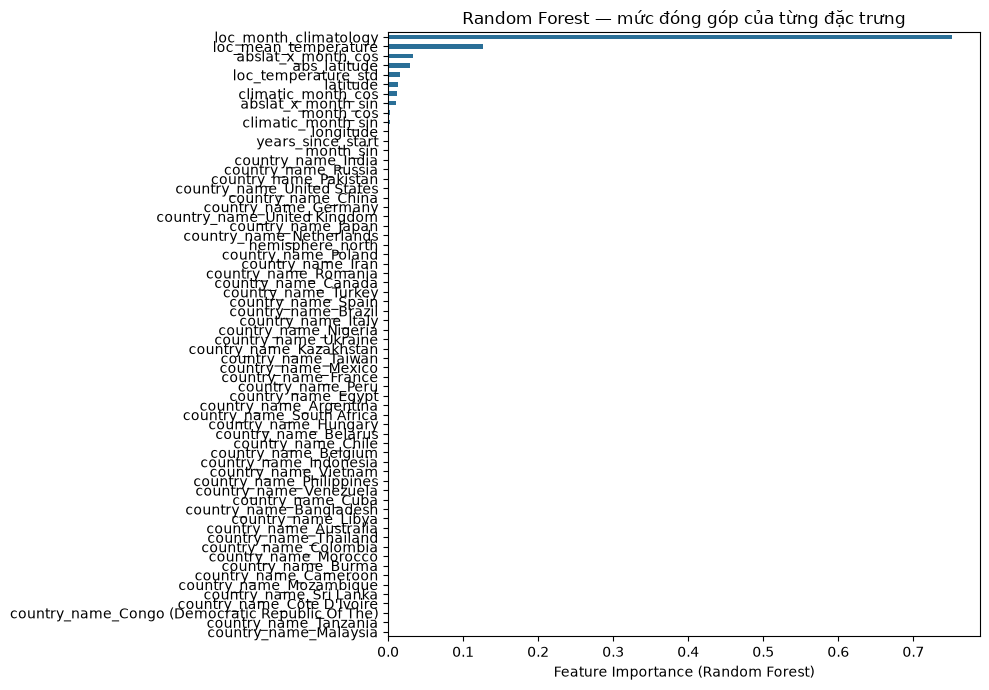

In [33]:
forest_transformed_features = transformed_feature_names(forest_pipeline)
forest_importance = (
    pd.Series(forest_model.feature_importances_, index=forest_transformed_features, name='Importance')
    .sort_values(ascending=False)
)
display(forest_importance.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
forest_importance.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title('Random Forest — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '12_random_forest_feature_importance.png', dpi=110)
plt.show()

### 5.6. Dự đoán trên tập validation

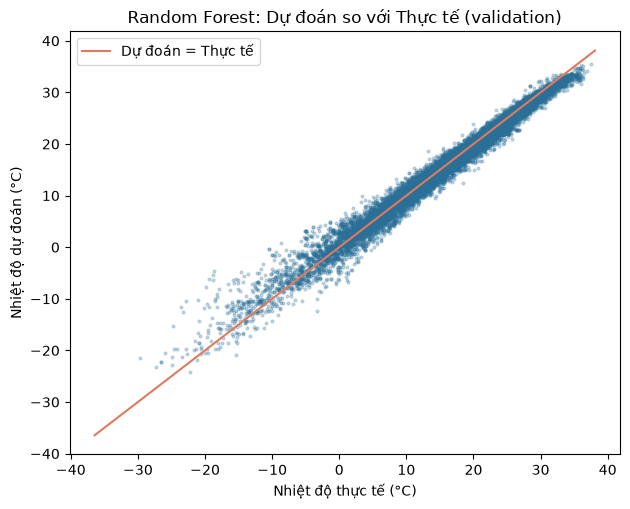

In [34]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(
    y_validation.to_numpy()[plot_positions], forest_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), forest_validation_pred.min())
value_max = max(y_validation.max(), forest_validation_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title('Random Forest: Dự đoán so với Thực tế (validation)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '13_random_forest_actual_vs_predicted.png', dpi=110)
plt.show()

#### Nhận xét biểu đồ validation

Biểu đồ dùng đúng mẫu validation đã dùng cho Linear Regression. So sánh độ tập trung quanh đường chéo và RMSE validation ở Mục 7, không kết luận từ riêng hình vẽ.


### 5.7. Dự đoán với giá trị đầu vào cụ thể


Lấy một dòng validation để minh họa Pipeline tự nhận feature số và `country_name`, sau đó trả về nhiệt độ dự đoán. Đây chỉ là kiểm tra lịch sử; ứng dụng tương lai sẽ tự tạo feature từ thành phố và tháng mục tiêu.

In [35]:
demo_row = validation_df.sample(n=1, random_state=RANDOM_SEED)
demo_features = demo_row[RF_FEATURES]
demo_prediction = forest_pipeline.predict(demo_features)[0]
demo_actual = demo_row[Y_COLUMN].iloc[0]

print(f"Thành phố   : {demo_row['city_name'].iloc[0]}, {demo_row['country_name'].iloc[0]}")
print(f"Ngày quan sát: {demo_row['observation_date'].dt.date.iloc[0]}")
print(f'Nhiệt độ thực tế : {demo_actual:.2f} °C')
print(f'Nhiệt độ dự đoán : {demo_prediction:.2f} °C')
print(f'Chênh lệch       : {demo_prediction - demo_actual:+.2f} °C')
display(demo_features.T.rename(columns={demo_features.index[0]: 'Giá trị đầu vào'}))

Thành phố   : Kuching, Malaysia
Ngày quan sát: 1987-06-01
Nhiệt độ thực tế : 27.55 °C
Nhiệt độ dự đoán : 26.73 °C
Chênh lệch       : -0.82 °C


,Giá trị đầu vào
month_sin,-0.0000
month_cos,-1.0000
climatic_month_sin,-0.0000
climatic_month_cos,-1.0000
years_since_start,124.0000
latitude,0.8000
abs_latitude,0.8000
hemisphere_north,1
longitude,110.0900
abslat_x_month_sin,-0.0000


### 5.8. Lưu mô hình Random Forest

In [36]:
FOREST_MODEL_PATH = CANDIDATES_DIR / 'random_forest_pipeline.pkl'
joblib.dump(forest_pipeline, FOREST_MODEL_PATH)

log_result(
    'Random Forest', y_train, forest_train_pred, y_validation, forest_validation_pred,
    forest_fit_seconds, FOREST_MODEL_PATH,
)
print(f'Đã lưu: {FOREST_MODEL_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu: random_forest_pipeline.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8325,1.2198,0.9858,0.8699,1.2787,0.9839,19.2116,0.0061
1,Random Forest,0.3781,0.6213,0.9963,0.9165,1.3493,0.9820,482.7263,"1,004.3946"


## 6. Mô hình XGBoost


### 6.1. Giới thiệu XGBoost

XGBoost cũng dùng nhiều cây quyết định như Random Forest, nhưng xây dựng **tuần tự**: mỗi cây mới được huấn luyện để sửa phần sai số mà các cây trước đó còn để lại (gradient boosting), thay vì các cây độc lập rồi lấy trung bình. Cách làm này thường chính xác hơn Random Forest trên cùng dữ liệu, nhưng dễ học vẹt hơn nếu không kiểm soát số cây.

Notebook dùng chính tập **validation** để kiểm soát rủi ro đó: huấn luyện dừng lại (early stopping) ngay khi sai số trên validation ngừng cải thiện, thay vì cố định trước số cây. Đây là cách dùng validation đúng mục đích của nó — chọn mô hình/hyperparameter — không phải là dùng tập test.

### 6.2. Lựa chọn Feature đầu vào cho XGBoost

XGBoost nhận cùng feature số và `country_name` one-hot. Numeric không cần scale, nhưng preprocessing vẫn nằm trong Pipeline để train/inference nhất quán.

In [37]:
XGB_FEATURES = list(X_ALL_COLUMNS)
print(f'XGBoost dùng {len(NUMERIC_FEATURES)} feature số + one-hot country.')

XGBoost dùng 14 feature số + one-hot country.


### 6.3. Huấn luyện mô hình XGBoost

`tree_method='hist'` là thuật toán chia nhánh theo histogram, hiệu quả trên vài triệu dòng. `n_estimators=500` là số cây **tối đa**; `early_stopping_rounds=20` sẽ dừng sớm nếu 20 vòng liên tiếp không cải thiện RMSE trên validation, tránh học vẹt và tiết kiệm thời gian.

#### 6.3.1. Khởi tạo XGBoost Pipeline

`tree_method='hist'` và early stopping giúp train hiệu quả trên dữ liệu lớn.


In [38]:
from xgboost import XGBRegressor

start_time = time.time()
xgboost_pipeline = make_model_pipeline(
    XGBRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        n_jobs=-1, random_state=RANDOM_SEED, eval_metric='rmse',
        early_stopping_rounds=20,
    ),
    scale_numeric=False,
)


#### 6.3.2. Fit preprocessing trên train

Preprocessor chỉ fit trên train rồi transform validation; không có leakage từ validation vào encoder/imputer.


In [39]:
xgb_preprocessor = xgboost_pipeline.named_steps['preprocessor']
X_train_xgb = xgb_preprocessor.fit_transform(X_train[XGB_FEATURES])
X_validation_xgb = xgb_preprocessor.transform(X_validation[XGB_FEATURES])
xgboost_model = xgboost_pipeline.named_steps['model']


#### 6.3.3. Huấn luyện với early stopping

Validation chỉ dùng theo dõi dừng sớm và đánh giá; số cây thực dùng có thể nhỏ hơn `n_estimators`.


In [40]:
xgboost_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_validation_xgb, y_validation)],
    verbose=False,
)
xgboost_fit_seconds = time.time() - start_time

print(f'Đã huấn luyện XGBoost trong {xgboost_fit_seconds:,.1f} giây.')
print(f'Số cây tối đa   : {xgboost_model.n_estimators}')
print(f'Số cây thực dùng: {xgboost_model.best_iteration + 1} (dừng sớm nhờ early stopping trên validation)')


Đã huấn luyện XGBoost trong 34.0 giây.
Số cây tối đa   : 500
Số cây thực dùng: 61 (dừng sớm nhờ early stopping trên validation)


### 6.4. Đánh giá mô hình XGBoost

In [41]:
xgboost_train_pred = xgboost_pipeline.predict(X_train[XGB_FEATURES])
xgboost_validation_pred = xgboost_pipeline.predict(X_validation[XGB_FEATURES])

xgboost_val_metrics = compute_metrics(y_validation, xgboost_validation_pred)
print('Đánh giá trên validation:')
for metric_name, value in xgboost_val_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

Đánh giá trên validation:
  MAE  : 0.8864
  RMSE : 1.3152
  R2   : 0.9829


### 6.5. Xem Feature Importance của XGBoost

XGBoost đo importance bằng "gain" — tổng mức giảm sai số mà một đặc trưng mang lại mỗi khi được dùng để chia nhánh, trung bình trên số lần dùng. Thứ tự importance giữa XGBoost và Random Forest có thể khác nhau vì cơ chế xây cây khác nhau (tuần tự sửa lỗi so với song song lấy trung bình).

,Importance (gain)
loc_month_climatology,"635,319.6250"
climatic_month_cos,"363,615.9688"
climatic_month_sin,"113,989.2266"
loc_mean_temperature,"92,805.8438"
abs_latitude,"19,030.5176"
...,...
country_name_Cuba,0.0000
country_name_Côte D'Ivoire,0.0000
country_name_Mozambique,0.0000
country_name_Malaysia,0.0000


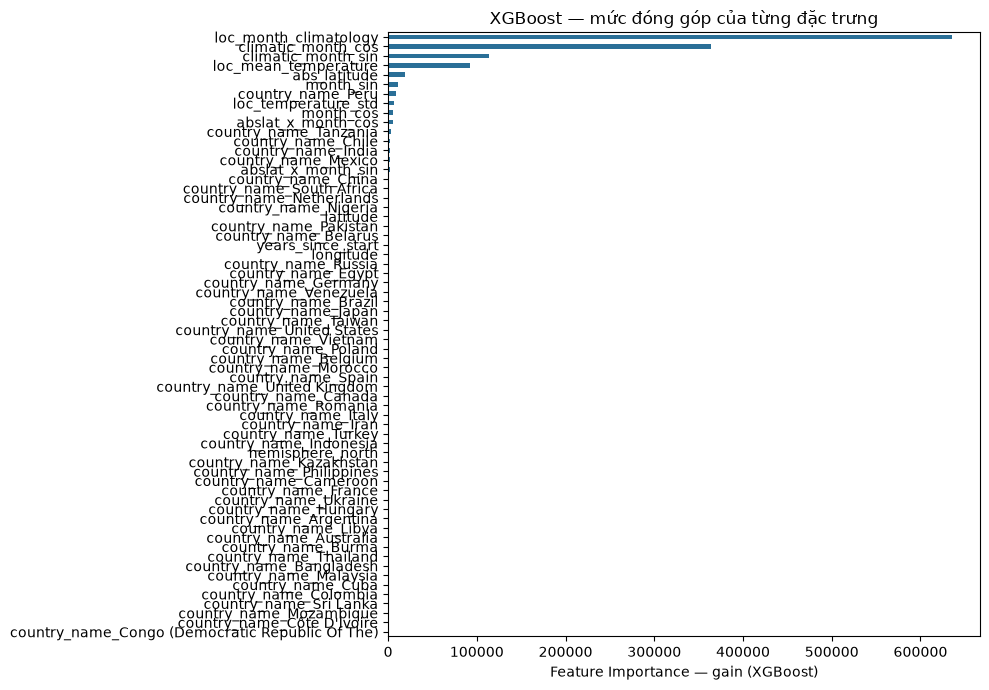

In [ ]:
xgboost_transformed_features = transformed_feature_names(xgboost_pipeline)
xgb_gain = xgboost_model.get_booster().get_score(importance_type='gain')
xgboost_importance = (
    pd.Series(
        [xgb_gain.get(f'f{index}', 0.0) for index in range(len(xgboost_transformed_features))],
        index=xgboost_transformed_features,
        name='Importance (gain)',
    )
    .sort_values(ascending=False)
)
display(xgboost_importance.to_frame())

fig, ax = plt.subplots(figsize=(10, 7))
xgboost_importance.sort_values().plot.barh(ax=ax, color='#2a6f97')
ax.set_xlabel('Feature Importance — gain (XGBoost)')
ax.set_title('XGBoost — mức đóng góp của từng đặc trưng')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '14_xgboost_feature_importance.png', dpi=110)
# hiển thị không bị trồng chữ ở cột y

plt.show()

Feature importance theo gain cho biết feature nào giúp giảm sai số nhiều khi cây chia nhánh. Giá trị này không phải tác động nhân quả và có thể phân tán giữa các cột one-hot.


### 6.6. Dự đoán trên tập validation


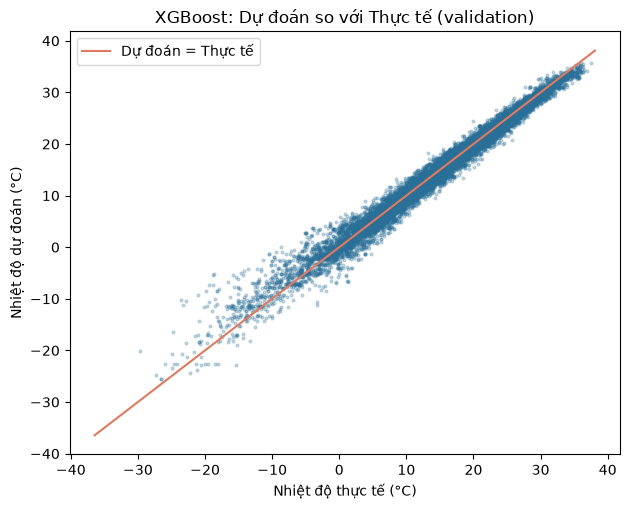

In [43]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.scatter(
    y_validation.to_numpy()[plot_positions], xgboost_validation_pred[plot_positions],
    s=4, alpha=0.25, color='#2a6f97',
)
value_min = min(y_validation.min(), xgboost_validation_pred.min())
value_max = max(y_validation.max(), xgboost_validation_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title('XGBoost: Dự đoán so với Thực tế (validation)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '15_xgboost_actual_vs_predicted.png', dpi=110)
plt.show()

#### Nhận xét biểu đồ validation

Đồ thị chỉ là kiểm tra trực quan. Kết luận chọn model vẫn dựa trên RMSE validation chung và khoảng cách train–validation ở Mục 8.1.


### 6.7. Dự đoán với giá trị đầu vào cụ thể


Dùng lại đúng dòng dữ liệu đã minh họa ở Mục 5.7 để so sánh trực tiếp dự đoán của Random Forest và XGBoost trên cùng một trường hợp.

In [44]:
xgboost_demo_prediction = xgboost_pipeline.predict(demo_features)[0]

print(f"Thành phố   : {demo_row['city_name'].iloc[0]}, {demo_row['country_name'].iloc[0]}")
print(f"Ngày quan sát: {demo_row['observation_date'].dt.date.iloc[0]}")
print(f'Nhiệt độ thực tế         : {demo_actual:.2f} °C')
print(f'Dự đoán Random Forest    : {demo_prediction:.2f} °C (chênh {demo_prediction - demo_actual:+.2f})')
print(f'Dự đoán XGBoost          : {xgboost_demo_prediction:.2f} °C (chênh {xgboost_demo_prediction - demo_actual:+.2f})')

Thành phố   : Kuching, Malaysia
Ngày quan sát: 1987-06-01
Nhiệt độ thực tế         : 27.55 °C
Dự đoán Random Forest    : 26.73 °C (chênh -0.82)
Dự đoán XGBoost          : 26.74 °C (chênh -0.81)


### 6.8. Lưu mô hình XGBoost

In [45]:
XGBOOST_MODEL_PATH = CANDIDATES_DIR / 'xgboost_pipeline.pkl'
joblib.dump(xgboost_pipeline, XGBOOST_MODEL_PATH)

log_result(
    'XGBoost', y_train, xgboost_train_pred, y_validation, xgboost_validation_pred,
    xgboost_fit_seconds, XGBOOST_MODEL_PATH,
)
print(f'Đã lưu: {XGBOOST_MODEL_PATH.name}')
display(pd.DataFrame(MODEL_RESULTS))

Đã lưu: xgboost_pipeline.pkl


,Mô hình,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
0,Linear Regression,0.8325,1.2198,0.9858,0.8699,1.2787,0.9839,19.2116,0.0061
1,Random Forest,0.3781,0.6213,0.9963,0.9165,1.3493,0.9820,482.7263,"1,004.3946"
2,XGBoost,0.7879,1.1583,0.9872,0.8864,1.3152,0.9829,33.9692,1.3692


## 7. So sánh mô hình và baseline


Bảng dưới đặt ba model cạnh climatology baseline. Baseline không cạnh tranh để triển khai; nó trả lời câu hỏi liệu Machine Learning có cải thiện hơn khí hậu trung bình theo city–month hay không.


In [46]:
baseline_table = pd.DataFrame(
    [baseline_validation_metrics], index=['Climatology baseline']
).rename(columns={'MAE': 'MAE (validation)', 'RMSE': 'RMSE (validation)', 'R2': 'R2 (validation)'})
print('Baseline không được dùng để chọn model, nhưng là mốc so sánh bắt buộc:')
display(baseline_table)

results_df = pd.DataFrame(MODEL_RESULTS).set_index('Mô hình')
display_columns = [
    'MAE (train)', 'RMSE (train)', 'R2 (train)',
    'MAE (validation)', 'RMSE (validation)', 'R2 (validation)',
    'Thời gian huấn luyện (giây)', 'Dung lượng file (MB)',
]
results_df = results_df[display_columns].sort_values('RMSE (validation)')
display(results_df)

summary_table = results_df[['MAE (validation)', 'RMSE (validation)', 'R2 (validation)']].round(4)
summary_table.columns = ['MAE', 'RMSE', 'R²']
print('Bảng so sánh rút gọn (trên validation):')
display(summary_table)

Baseline không được dùng để chọn model, nhưng là mốc so sánh bắt buộc:


,MAE (validation),RMSE (validation),R2 (validation)
Climatology baseline,0.9734,1.3664,0.9816


,MAE (train),RMSE (train),R2 (train),MAE (validation),RMSE (validation),R2 (validation),Thời gian huấn luyện (giây),Dung lượng file (MB)
Mô hình,,,,,,,,
Linear Regression,0.8325,1.2198,0.9858,0.8699,1.2787,0.9839,19.2116,0.0061
XGBoost,0.7879,1.1583,0.9872,0.8864,1.3152,0.9829,33.9692,1.3692
Random Forest,0.3781,0.6213,0.9963,0.9165,1.3493,0.9820,482.7263,"1,004.3946"


Bảng so sánh rút gọn (trên validation):


,MAE,RMSE,R²
Mô hình,,,
Linear Regression,0.8699,1.2787,0.9839
XGBoost,0.8864,1.3152,0.9829
Random Forest,0.9165,1.3493,0.9820


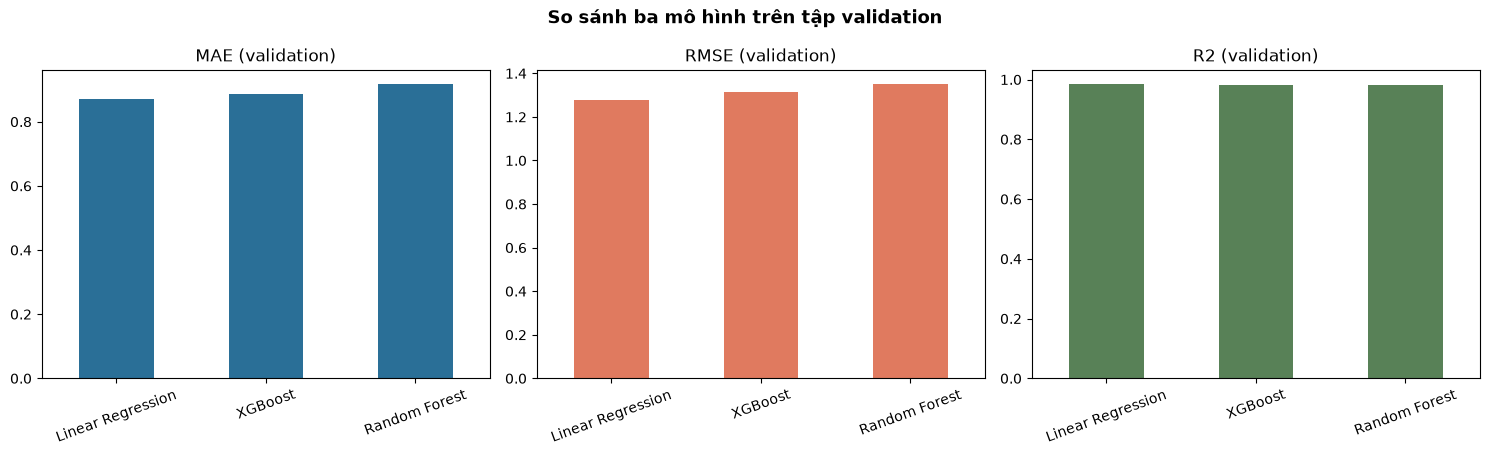

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
metric_columns = ['MAE (validation)', 'RMSE (validation)', 'R2 (validation)']
colors = ['#2a6f97', '#e07a5f', '#588157']

for ax, metric_column, color in zip(axes, metric_columns, colors):
    plot_order = results_df[metric_column].sort_values(ascending=metric_column != 'R2 (validation)')
    plot_order.plot.bar(ax=ax, color=color)
    ax.set_title(metric_column)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('So sánh ba mô hình trên tập validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '16_model_comparison.png', dpi=110)
plt.show()

#### Nhận xét bảng và biểu đồ so sánh

So sánh theo từng metric giúp tránh chọn model chỉ vì R² cao. Model được chọn phải có RMSE validation thấp nhất, đồng thời thời gian huấn luyện và mức chênh train–validation phù hợp để triển khai.


### 7.1. Ablation Study: đóng góp của từng nhóm feature

Ablation Study đo trực tiếp mức đóng góp tăng thêm của từng **nhóm feature** đối với Linear Regression. Mỗi cấu hình dùng cùng tập Train, Validation, target và quy trình preprocessing; chỉ tập feature được thay đổi. Vì vậy, chênh lệch RMSE phản ánh giá trị tăng thêm của nhóm feature vừa được bổ sung.

Thí nghiệm dùng Validation, không dùng Test. Tập Test chỉ được mở một lần sau khi đã chốt mô hình và bộ feature đầy đủ. `Climatology only` ở đây là một Linear Regression chỉ dùng ba thống kê khí hậu nền theo vị trí; khác với climatology baseline trực tiếp ở Mục 7, vốn chỉ dùng riêng `loc_month_climatology` làm giá trị dự đoán.


#### 7.1.1. Khai báo các nhóm feature

Các cấu hình được bổ sung theo thứ tự tích lũy. `Full model (+ Country)` phải khớp chính xác 14 feature số và một feature phân loại (`country_name`) mà Notebook 05 đã bàn giao.


In [48]:
CLIMATE_FEATURES = [
    'loc_month_climatology',
    'loc_mean_temperature',
    'loc_temperature_std',
]
SEASONALITY_FEATURES = [
    'month_sin', 'month_cos',
    'climatic_month_sin', 'climatic_month_cos',
]
GEOGRAPHY_FEATURES = [
    'latitude', 'abs_latitude', 'hemisphere_north', 'longitude',
]
GEOGRAPHY_SEASON_INTERACTIONS = [
    'abslat_x_month_sin', 'abslat_x_month_cos',
]
TIME_TREND_FEATURES = ['years_since_start']

ABLATION_CONFIGS = [
    ('Climatology only', CLIMATE_FEATURES, []),
    ('+ Seasonality', CLIMATE_FEATURES + SEASONALITY_FEATURES, []),
    ('+ Geography', CLIMATE_FEATURES + SEASONALITY_FEATURES + GEOGRAPHY_FEATURES, []),
    (
        '+ Geography × season',
        CLIMATE_FEATURES + SEASONALITY_FEATURES + GEOGRAPHY_FEATURES
        + GEOGRAPHY_SEASON_INTERACTIONS,
        [],
    ),
    (
        '+ Time trend',
        CLIMATE_FEATURES + SEASONALITY_FEATURES + GEOGRAPHY_FEATURES
        + GEOGRAPHY_SEASON_INTERACTIONS + TIME_TREND_FEATURES,
        [],
    ),
    ('Full model (+ Country)', NUMERIC_FEATURES, CATEGORICAL_FEATURES),
]

expected_full_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES
configured_full_features = ABLATION_CONFIGS[-1][1] + ABLATION_CONFIGS[-1][2]
if configured_full_features != expected_full_features:
    raise RuntimeError('Cấu hình Full model không khớp feature contract của Notebook 05.')

for name, numeric_features, categorical_features in ABLATION_CONFIGS:
    print(f'{name:<26}: {len(numeric_features)} feature số + {len(categorical_features)} feature phân loại')


Climatology only          : 3 feature số + 0 feature phân loại
+ Seasonality             : 7 feature số + 0 feature phân loại
+ Geography               : 11 feature số + 0 feature phân loại
+ Geography × season      : 13 feature số + 0 feature phân loại
+ Time trend              : 14 feature số + 0 feature phân loại
Full model (+ Country)    : 14 feature số + 1 feature phân loại


#### 7.1.2. Huấn luyện Linear Regression theo từng cấu hình

Preprocessing của mỗi cấu hình chỉ được `fit` trên Train. Nếu có `country_name`, One-Hot Encoder cũng chỉ học các quốc gia xuất hiện trong Train; nhờ đó validation không đi ngược vào quá trình fit.


In [49]:
def make_ablation_pipeline(numeric_features, categorical_features):
    """Tạo Pipeline Linear Regression cho một cấu hình feature cụ thể."""
    transformers = [
        (
            'numeric',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        )
    ]

    if categorical_features:
        transformers.append(
            (
                'country',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]),
                categorical_features,
            )
        )

    return Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=transformers,
            remainder='drop',
            verbose_feature_names_out=False,
        )),
        ('model', LinearRegression()),
    ])


ablation_rows = []
for config_name, numeric_features, categorical_features in ABLATION_CONFIGS:
    feature_columns = numeric_features + categorical_features
    pipeline = make_ablation_pipeline(numeric_features, categorical_features)

    start_time = time.time()
    pipeline.fit(X_train[feature_columns], y_train)
    fit_seconds = time.time() - start_time
    validation_prediction = pipeline.predict(X_validation[feature_columns])
    metrics = compute_metrics(y_validation, validation_prediction)

    ablation_rows.append({
        'Bộ feature': config_name,
        'Số feature số': len(numeric_features),
        'Số feature phân loại': len(categorical_features),
        'MAE (validation)': metrics['MAE'],
        'RMSE (validation)': metrics['RMSE'],
        'R² (validation)': metrics['R2'],
        'Thời gian fit (giây)': fit_seconds,
    })
    print(f'{config_name:<26} | RMSE validation = {metrics["RMSE"]:.4f} °C')

ABLATION_RESULTS = pd.DataFrame(ablation_rows)
ABLATION_RESULTS['Cải thiện RMSE so với cấu hình trước (°C)'] = (
    ABLATION_RESULTS['RMSE (validation)'].shift(1)
    - ABLATION_RESULTS['RMSE (validation)']
)
display(ABLATION_RESULTS.round(4))


Climatology only           | RMSE validation = 1.3661 °C
+ Seasonality              | RMSE validation = 1.3661 °C
+ Geography                | RMSE validation = 1.3661 °C
+ Geography × season       | RMSE validation = 1.3661 °C
+ Time trend               | RMSE validation = 1.2786 °C
Full model (+ Country)     | RMSE validation = 1.2787 °C


,Bộ feature,Số feature số,Số feature phân loại,MAE (validation),RMSE (validation),R² (validation),Thời gian fit (giây),Cải thiện RMSE so với cấu hình trước (°C)
0,Climatology only,3,0,0.9733,1.3661,0.9816,1.3476,NaN
1,+ Seasonality,7,0,0.9733,1.3661,0.9816,2.2410,0.0000
2,+ Geography,11,0,0.9733,1.3661,0.9816,3.7790,0.0000
3,+ Geography × season,13,0,0.9733,1.3661,0.9816,4.8259,0.0000
4,+ Time trend,14,0,0.8698,1.2786,0.9839,5.2420,0.0875
5,Full model (+ Country),14,1,0.8699,1.2787,0.9839,18.8705,-0.0001


#### 7.1.3. Trực quan hóa mức thay đổi RMSE

RMSE càng thấp càng tốt. Cột “cải thiện RMSE” dương nghĩa là nhóm feature vừa bổ sung giúp giảm sai số so với cấu hình liền trước; giá trị âm nghĩa là cấu hình đó không cải thiện trong thứ tự tích lũy đang xét.


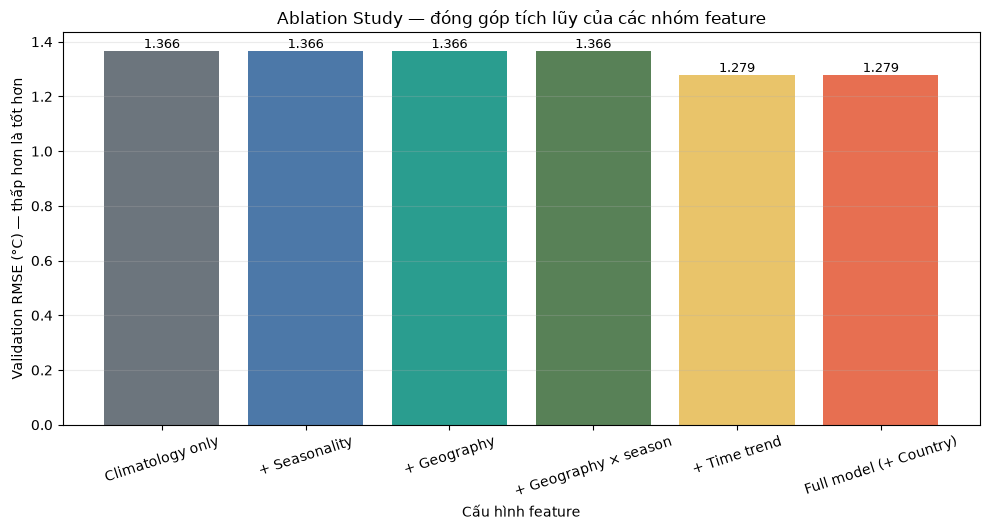

Full model RMSE validation: 1.2787 °C


In [50]:
fig, ax = plt.subplots(figsize=(10, 5.4))
plot_data = ABLATION_RESULTS.copy()
bars = ax.bar(
    plot_data['Bộ feature'],
    plot_data['RMSE (validation)'],
    color=['#6c757d', '#4c78a8', '#2a9d8f', '#588157', '#e9c46a', '#e76f51'],
)

for bar, value in zip(bars, plot_data['RMSE (validation)']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.3f}',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_xlabel('Cấu hình feature')
ax.set_ylabel('Validation RMSE (°C) — thấp hơn là tốt hơn')
ax.set_title('Ablation Study — đóng góp tích lũy của các nhóm feature')
ax.tick_params(axis='x', rotation=18)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '17_ablation_study_validation_rmse.png', dpi=110)
plt.show()

full_model_rmse = ABLATION_RESULTS.iloc[-1]['RMSE (validation)']
print(f'Full model RMSE validation: {full_model_rmse:.4f} °C')


#### Nhận xét Ablation Study

Kết quả phải được đọc theo thứ tự tích lũy của bảng: mức thay đổi RMSE của một hàng là đóng góp **có điều kiện** của nhóm feature mới, khi các nhóm ở các hàng trước đã hiện diện. Ablation Study không thay thế feature importance và không khẳng định quan hệ nhân quả; nó là bằng chứng thực nghiệm về giá trị dự báo tăng thêm của từng nhóm feature trên tập Validation.


## 8. Lựa chọn, backtest và đánh giá cuối


### 8.1. Giải thích lựa chọn bằng số liệu

Việc chọn mô hình dựa trước hết vào RMSE validation, rồi cân nhắc khoảng cách train–validation (dấu hiệu overfit), thời gian huấn luyện và kích thước artifact. Cả ba model đều được lưu dưới dạng Pipeline, nên preprocessing nằm bên trong `model.pkl`; không có `scaler.pkl` riêng.

#### 8.1.1. Chọn model theo RMSE validation

Mô hình có RMSE validation thấp nhất là ứng viên phát hành.


In [51]:
best_model_name = results_df['RMSE (validation)'].idxmin()
best_row = results_df.loc[best_model_name]

print(f'>>> Mô hình có RMSE thấp nhất trên validation: {best_model_name}\n')

for model_name, row in results_df.iterrows():
    generalization_gap = row['RMSE (validation)'] - row['RMSE (train)']
    marker = '★ ĐƯỢC CHỌN' if model_name == best_model_name else ''
    print(f'{model_name:<18} {marker}')
    print(f'  RMSE validation      : {row["RMSE (validation)"]:.4f} °C')
    print(f'  R² validation        : {row["R2 (validation)"]:.4f}')
    print(f'  Chênh lệch RMSE (validation - train): {generalization_gap:+.4f} '
          f'{"(gần 0, ít dấu hiệu overfit)" if abs(generalization_gap) < 0.15 else "(chênh lệch đáng chú ý)"}')
    print(f'  Thời gian huấn luyện : {row["Thời gian huấn luyện (giây)"]:.1f} giây')
    print(f'  Dung lượng file      : {row["Dung lượng file (MB)"]:.2f} MB'
          + ' (Pipeline đã chứa preprocessing)')
    print()


>>> Mô hình có RMSE thấp nhất trên validation: Linear Regression

Linear Regression  ★ ĐƯỢC CHỌN
  RMSE validation      : 1.2787 °C
  R² validation        : 0.9839
  Chênh lệch RMSE (validation - train): +0.0589 (gần 0, ít dấu hiệu overfit)
  Thời gian huấn luyện : 19.2 giây
  Dung lượng file      : 0.01 MB (Pipeline đã chứa preprocessing)

XGBoost            
  RMSE validation      : 1.3152 °C
  R² validation        : 0.9829
  Chênh lệch RMSE (validation - train): +0.1569 (chênh lệch đáng chú ý)
  Thời gian huấn luyện : 34.0 giây
  Dung lượng file      : 1.37 MB (Pipeline đã chứa preprocessing)

Random Forest      
  RMSE validation      : 1.3493 °C
  R² validation        : 0.9820
  Chênh lệch RMSE (validation - train): +0.7281 (chênh lệch đáng chú ý)
  Thời gian huấn luyện : 482.7 giây
  Dung lượng file      : 1004.39 MB (Pipeline đã chứa preprocessing)



#### 8.1.2. So sánh với model đứng thứ hai

Khoảng cách RMSE cho biết mức cải thiện tuyệt đối, không thay thế đánh giá test cuối.


In [52]:
rmse_gap_vs_second = (
    results_df['RMSE (validation)'].sort_values().iloc[1]
    - results_df['RMSE (validation)'].sort_values().iloc[0]
)
print(
    f'{best_model_name} vượt mô hình xếp thứ hai {rmse_gap_vs_second:.4f} °C RMSE trên validation '
    f'({rmse_gap_vs_second / results_df["RMSE (validation)"].sort_values().iloc[1] * 100:.1f}% thấp hơn).'
)


Linear Regression vượt mô hình xếp thứ hai 0.0365 °C RMSE trên validation (2.8% thấp hơn).


**Đọc kết quả ở trên để trả lời ba câu hỏi mà đề cương yêu cầu:**

- *Vì sao chọn mô hình có RMSE thấp nhất?* Vì đây là chỉ số đo trực tiếp sai số dự đoán theo đúng đơn vị bài toán (°C), đo trên tập validation chưa từng được dùng để huấn luyện.
- *Vì sao không chỉ nhìn RMSE?* Một mô hình có RMSE thấp trên validation nhưng chênh lệch train/validation lớn có nguy cơ chỉ đang "nhớ" đặc điểm giai đoạn 1984–1993 thay vì học được quan hệ tổng quát — điều này chỉ lộ ra khi so sánh với RMSE trên train.
- *Thời gian huấn luyện và triển khai có quan trọng không?* Có — nếu hai mô hình gần bằng nhau về độ chính xác, mô hình huấn luyện nhanh hơn và có artifact gọn hơn sẽ dễ vận hành hơn. Cả ba lựa chọn đều đóng gói xử lý số và one-hot `country_name` trong `model.pkl`.

### 8.2. Rolling-origin backtest cho horizon 1–12 tháng

Validation một giai đoạn (1984–1993) vẫn dùng để chọn mô hình. Khối kiểm tra này bổ sung **rolling-origin backtest**: tại mỗi mốc lịch sử, mô hình chỉ được fit bằng dữ liệu có ngày không muộn hơn mốc đó, rồi dự báo tối đa 12 tháng kế tiếp. Vì thế phép đo phản ánh đúng hơn việc dự báo nhiều horizon; tập `test` 1994–2013 vẫn chưa tham gia.

Để notebook chạy được trên máy cá nhân, mỗi mốc lấy tối đa 250.000 dòng train theo mẫu ngẫu nhiên có seed cố định. Nếu đủ tài nguyên, có thể đặt `ROLLING_MAX_TRAIN_ROWS = None` để dùng toàn bộ dữ liệu lịch sử.

#### 8.2.1. Khai báo rolling origins

Mỗi origin fit lại model từ dữ liệu quá khứ và dự báo tối đa 12 tháng sau đó.


In [53]:
ROLLING_ORIGINS = pd.to_datetime(['1983-12-01', '1986-12-01', '1989-12-01'])
ROLLING_MAX_TRAIN_ROWS = 250_000  # Đặt None nếu muốn fit toàn bộ dữ liệu tại mỗi mốc.


def make_rolling_pipeline(model_name: str) -> Pipeline:
    if model_name == 'Linear Regression':
        return make_model_pipeline(LinearRegression(), scale_numeric=True)
    if model_name == 'Random Forest':
        return make_model_pipeline(
            RandomForestRegressor(**forest_model.get_params()), scale_numeric=False
        )

    best_iteration = getattr(xgboost_model, 'best_iteration', None)
    best_n_estimators = int(best_iteration + 1) if best_iteration is not None else xgboost_model.n_estimators
    params = xgboost_model.get_params()
    params['n_estimators'] = best_n_estimators
    params.pop('early_stopping_rounds', None)
    return make_model_pipeline(XGBRegressor(**params), scale_numeric=False)


#### 8.2.2. Chạy backtest tại từng origin

Train tại mỗi origin có thể được lấy mẫu để thời gian chạy hợp lý; validation tương lai vẫn không đi ngược vào train.


In [54]:
rolling_rows = []
for origin in ROLLING_ORIGINS:
    # observation_date là cột thời gian đã được Notebook 05 bàn giao.
    origin_train = df_clean.loc[df_clean['observation_date'] <= origin].copy()
    future = df_clean.loc[
        (df_clean['observation_date'] > origin)
        & (df_clean['observation_date'] <= origin + pd.DateOffset(months=12))
        & (df_clean['data_split'] == 'validation')
    ].copy()

    if ROLLING_MAX_TRAIN_ROWS is not None and len(origin_train) > ROLLING_MAX_TRAIN_ROWS:
        origin_train = origin_train.sample(ROLLING_MAX_TRAIN_ROWS, random_state=RANDOM_SEED)

    if future.empty:
        print(f'Bỏ qua mốc {origin:%Y-%m}: không có nhãn validation trong 12 tháng sau.')
        continue

    rolling_model = make_rolling_pipeline(best_model_name)
    rolling_model.fit(origin_train[X_ALL_COLUMNS], origin_train[Y_COLUMN])
    model_pred = rolling_model.predict(future[X_ALL_COLUMNS])
    baseline_pred = future['loc_month_climatology'].to_numpy()

    result_frame = future[['observation_date', Y_COLUMN]].copy()
    result_frame['horizon_month'] = (
        (result_frame['observation_date'].dt.year - origin.year) * 12
        + result_frame['observation_date'].dt.month - origin.month
    )
    for method, prediction in {best_model_name: model_pred, 'Climatology baseline': baseline_pred}.items():
        for horizon, group in result_frame.assign(prediction=prediction).groupby('horizon_month'):
            metrics = compute_metrics(group[Y_COLUMN], group['prediction'])
            rolling_rows.append({
                'origin': origin.strftime('%Y-%m'),
                'method': method,
                'horizon_month': int(horizon),
                'rows': len(group),
                **metrics,
            })


#### 8.2.3. Tổng hợp RMSE theo horizon

Đặt model cạnh climatology baseline ở từng horizon 1–12 tháng.


,method,horizon_month,rows,MAE,RMSE,R2
0,Climatology baseline,1,9357,1.4327,2.0624,0.9745
1,Climatology baseline,2,9357,1.4874,2.0716,0.9656
2,Climatology baseline,3,9357,1.3857,1.8641,0.9642
3,Climatology baseline,4,9357,0.9071,1.1875,0.9813
4,Climatology baseline,5,9357,1.0343,1.3334,0.9658
5,Climatology baseline,6,9357,0.8267,1.0208,0.9732
6,Climatology baseline,7,9357,0.7946,1.0015,0.9641
7,Climatology baseline,8,9357,0.7978,1.0047,0.9636
8,Climatology baseline,9,9357,0.7898,1.0142,0.9708
9,Climatology baseline,10,9357,0.9703,1.2239,0.9730


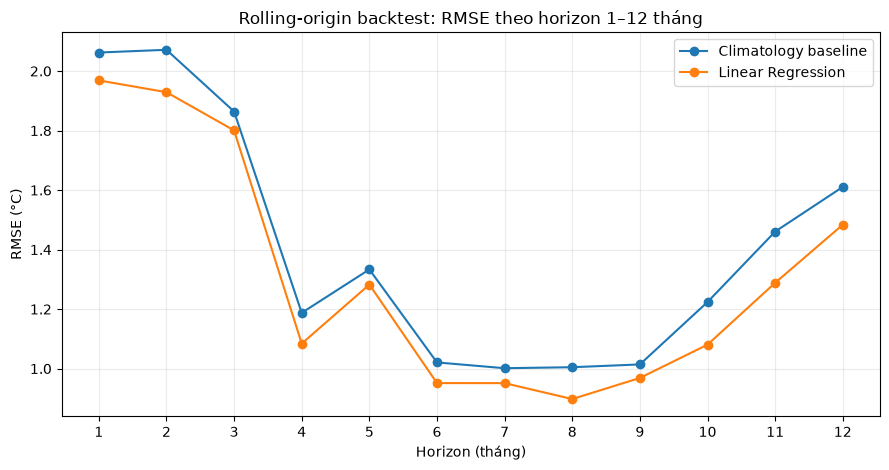

In [55]:
ROLLING_BACKTEST_DETAIL = pd.DataFrame(rolling_rows)
if ROLLING_BACKTEST_DETAIL.empty:
    raise RuntimeError('Rolling-origin backtest không tạo được kết quả; kiểm tra cột date và data_split.')

ROLLING_BACKTEST_SUMMARY = (
    ROLLING_BACKTEST_DETAIL
    .groupby(['method', 'horizon_month'], as_index=False)
    .agg(rows=('rows', 'sum'), MAE=('MAE', 'mean'), RMSE=('RMSE', 'mean'), R2=('R2', 'mean'))
)
display(ROLLING_BACKTEST_SUMMARY.round(4))

fig, ax = plt.subplots(figsize=(9, 4.8))
for method, group in ROLLING_BACKTEST_SUMMARY.groupby('method'):
    ax.plot(group['horizon_month'], group['RMSE'], marker='o', label=method)
ax.set(xlabel='Horizon (tháng)', ylabel='RMSE (°C)', xticks=range(1, 13),
       title='Rolling-origin backtest: RMSE theo horizon 1–12 tháng')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '17a_rolling_origin_rmse.png', dpi=110)
plt.show()


Diễn giải: nếu RMSE của model thấp hơn baseline ở phần lớn horizon, model có giá trị tăng thêm ngoài khí hậu nền. Backtest lịch sử kiểm tra horizon 1–12 tháng, không chứng minh độ chính xác thời tiết cho các năm rất xa sau 2013.


### 8.3. Huấn luyện lại mô hình được chọn trên Train + Validation

In [56]:
train_plus_validation_df = pd.concat([train_df, validation_df], ignore_index=True)
X_train_val = train_plus_validation_df[X_ALL_COLUMNS]
y_train_val = train_plus_validation_df[Y_COLUMN]

print(f'Dữ liệu huấn luyện cuối cùng (train + validation): {len(train_plus_validation_df):,} dòng.')

if best_model_name == 'Linear Regression':
    final_model = make_model_pipeline(LinearRegression(), scale_numeric=True)
elif best_model_name == 'Random Forest':
    final_model = make_model_pipeline(
        RandomForestRegressor(**forest_model.get_params()), scale_numeric=False
    )
else:
    best_iteration = getattr(xgboost_model, 'best_iteration', None)
    best_n_estimators = int(best_iteration + 1) if best_iteration is not None else xgboost_model.n_estimators
    final_params = xgboost_model.get_params()
    final_params['n_estimators'] = best_n_estimators
    final_params.pop('early_stopping_rounds', None)
    final_model = make_model_pipeline(XGBRegressor(**final_params), scale_numeric=False)

final_model.fit(X_train_val, y_train_val)
print(f'Đã huấn luyện lại trọn Pipeline {best_model_name} trên train + validation.')

Dữ liệu huấn luyện cuối cùng (train + validation): 4,842,607 dòng.
Đã huấn luyện lại trọn Pipeline Linear Regression trên train + validation.


### 8.4. Đánh giá lần duy nhất trên tập Test

Đây là **lần duy nhất** tập test được dùng trong toàn bộ notebook. Số liệu dưới đây là con số báo cáo chính thức của dự án — không được dùng để quay lại chỉnh sửa mô hình hay đặc trưng.

=== Kết quả chính thức trên TEST (1994–2013) — mô hình: Linear Regression ===
  MAE  : 0.9238
  RMSE : 1.3297
  R2   : 0.9824


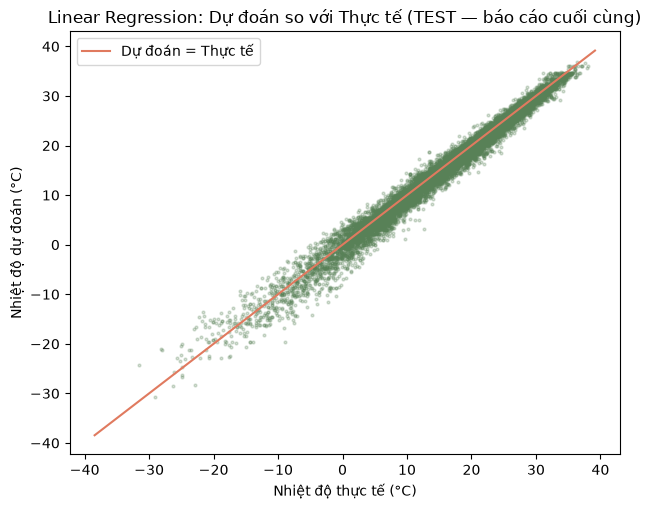

In [57]:
final_test_pred = final_model.predict(X_test[X_ALL_COLUMNS])
final_test_metrics = compute_metrics(y_test, final_test_pred)

print(f'=== Kết quả chính thức trên TEST (1994–2013) — mô hình: {best_model_name} ===')
for metric_name, value in final_test_metrics.items():
    print(f'  {metric_name:<5}: {value:,.4f}')

fig, ax = plt.subplots(figsize=(6.4, 5.2))
test_plot_positions = plot_rng.choice(len(y_test), size=min(PLOT_SAMPLE_SIZE, len(y_test)), replace=False)
ax.scatter(
    y_test.to_numpy()[test_plot_positions], final_test_pred[test_plot_positions],
    s=4, alpha=0.25, color='#588157',
)
value_min = min(y_test.min(), final_test_pred.min())
value_max = max(y_test.max(), final_test_pred.max())
ax.plot([value_min, value_max], [value_min, value_max], color='#e07a5f', linewidth=1.5, label='Dự đoán = Thực tế')
ax.set_xlabel('Nhiệt độ thực tế (°C)')
ax.set_ylabel('Nhiệt độ dự đoán (°C)')
ax.set_title(f'{best_model_name}: Dự đoán so với Thực tế (TEST — báo cáo cuối cùng)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '17_final_model_test_actual_vs_predicted.png', dpi=110)
plt.show()

Lưu ý khi đọc số liệu test: dữ liệu lịch sử chỉ đến tháng 09/2013. Test được giữ riêng đến bước này để báo cáo khả năng tổng quát trên giai đoạn chưa từng tham gia việc chọn model. Vì pipeline mới không dùng lag hay đặc trưng bối cảnh toàn cầu cùng tháng, việc 2013 thiếu ba tháng cuối không làm thiếu feature đầu vào.

#### 8.4.1. Kịch bản dự báo 12 tháng cho một thành phố

Phần này tạo một biểu đồ minh họa cho đủ 12 tháng của một năm tương lai. Đây là **kịch bản trực tiếp từ mô hình**, không phải dữ liệu quan sát thực tế. Có thể đổi tên thành phố, quốc gia và năm ở cell cấu hình bên dưới.


In [58]:
# Cấu hình kịch bản minh họa; đặt None để notebook tự chọn một vị trí đủ 12 tháng.
DEMO_CITY_NAME = 'Hanoi'
DEMO_COUNTRY_NAME = 'Vietnam'
DEMO_FORECAST_YEAR = 2026

# Chỉ giữ các vị trí có đủ 12 tháng tham chiếu để dựng climatology cho cả năm.
location_candidates = (
    df_clean.groupby(['city_name', 'country_name', 'latitude', 'longitude'], as_index=False)
    .agg(month_count=('month', 'nunique'), row_count=('month', 'size'))
    .query('month_count == 12')
    .sort_values(['row_count', 'city_name'], ascending=[False, True])
)

requested_location = location_candidates.loc[
    (location_candidates['city_name'] == DEMO_CITY_NAME)
    & (location_candidates['country_name'] == DEMO_COUNTRY_NAME)
]
demo_location = requested_location.iloc[0] if not requested_location.empty else location_candidates.iloc[0]

demo_history = df_clean.loc[
    (df_clean['city_name'] == demo_location['city_name'])
    & (df_clean['country_name'] == demo_location['country_name'])
    & (df_clean['latitude'] == demo_location['latitude'])
    & (df_clean['longitude'] == demo_location['longitude'])
].copy()

print(
    'Vị trí minh họa:',
    f"{demo_location['city_name']} ({demo_location['country_name']}) — ",
    f"{demo_location['latitude']:.2f}, {demo_location['longitude']:.2f}"
)
if requested_location.empty:
    print('Không tìm thấy thành phố yêu cầu; notebook đã dùng vị trí thay thế có đủ 12 tháng.')


Vị trí minh họa: Hanoi (Vietnam) —  21.70, 106.44


In [59]:
# Lấy thống kê khí hậu nền theo từng tháng từ dữ liệu lịch sử của vị trí đã chọn.
month_reference = (
    demo_history.sort_values('observation_date')
    .groupby('month', as_index=False)
    .tail(1)
    .set_index('month')
    .reindex(range(1, 13))
)

if month_reference['loc_month_climatology'].isna().any():
    raise RuntimeError('Vị trí minh họa thiếu climatology theo một hoặc nhiều tháng.')

scenario_features = month_reference[FEATURE_NAMES].copy().reset_index(drop=True)
months = np.arange(1, 13)
latitude = float(demo_location['latitude'])

# Tạo lại các feature chỉ phụ thuộc vào tháng, năm kịch bản và vị trí.
scenario_features['month_sin'] = np.sin(2 * np.pi * months / 12)
scenario_features['month_cos'] = np.cos(2 * np.pi * months / 12)
climatic_month = months if latitude >= 0 else ((months + 5) % 12) + 1
scenario_features['climatic_month_sin'] = np.sin(2 * np.pi * climatic_month / 12)
scenario_features['climatic_month_cos'] = np.cos(2 * np.pi * climatic_month / 12)
scenario_features['years_since_start'] = DEMO_FORECAST_YEAR - 1863
scenario_features['abslat_x_month_sin'] = abs(latitude) * scenario_features['month_sin']
scenario_features['abslat_x_month_cos'] = abs(latitude) * scenario_features['month_cos']
scenario_features['country_name'] = demo_location['country_name']

scenario_features = scenario_features[FEATURE_NAMES]
print('Đã tạo đúng', scenario_features.shape[1], 'feature cho 12 tháng kịch bản.')


Đã tạo đúng 15 feature cho 12 tháng kịch bản.


In [60]:
# Dự báo trực tiếp 12 tháng bằng Pipeline cuối cùng đã được chọn.
scenario_predictions = final_model.predict(scenario_features)
FORECAST_SCENARIO_12_MONTHS = pd.DataFrame({
    'month': months,
    'forecast_temperature_c': scenario_predictions,
})
FORECAST_SCENARIO_12_MONTHS['city_name'] = demo_location['city_name']
FORECAST_SCENARIO_12_MONTHS['country_name'] = demo_location['country_name']
FORECAST_SCENARIO_12_MONTHS['forecast_year'] = DEMO_FORECAST_YEAR

display(FORECAST_SCENARIO_12_MONTHS.round(2))
print('Đây là kịch bản mô hình; không đối chiếu với nhiệt độ quan sát của năm tương lai.')


,month,forecast_temperature_c,city_name,country_name,forecast_year
0,1,14.4800,Hanoi,Vietnam,2026
1,2,15.3900,Hanoi,Vietnam,2026
2,3,18.6800,Hanoi,Vietnam,2026
3,4,22.7900,Hanoi,Vietnam,2026
4,5,26.5300,Hanoi,Vietnam,2026
5,6,28.0200,Hanoi,Vietnam,2026
6,7,28.2600,Hanoi,Vietnam,2026
7,8,27.6500,Hanoi,Vietnam,2026
8,9,26.3400,Hanoi,Vietnam,2026
9,10,23.3600,Hanoi,Vietnam,2026


Đây là kịch bản mô hình; không đối chiếu với nhiệt độ quan sát của năm tương lai.


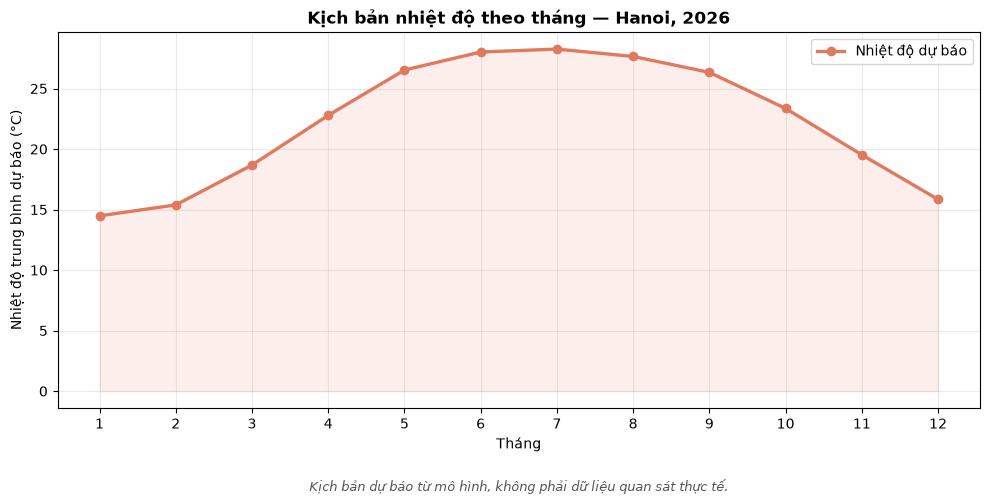

Đã lưu biểu đồ: reports\images\18_forecast_scenario_12_months.png


In [61]:
# Vẽ và lưu biểu đồ dùng cho báo cáo.
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(
    FORECAST_SCENARIO_12_MONTHS['month'],
    FORECAST_SCENARIO_12_MONTHS['forecast_temperature_c'],
    marker='o', linewidth=2.4, color='#e07a5f', label='Nhiệt độ dự báo',
)
ax.fill_between(
    FORECAST_SCENARIO_12_MONTHS['month'],
    FORECAST_SCENARIO_12_MONTHS['forecast_temperature_c'],
    alpha=0.12, color='#e07a5f',
)
ax.set_xticks(months)
ax.set_xlabel('Tháng')
ax.set_ylabel('Nhiệt độ trung bình dự báo (°C)')
ax.set_title(
    f"Kịch bản nhiệt độ theo tháng — {demo_location['city_name']}, {DEMO_FORECAST_YEAR}",
    fontweight='bold',
)
ax.grid(alpha=0.25)
ax.legend()
ax.text(
    0.5, -0.22,
    'Kịch bản dự báo từ mô hình, không phải dữ liệu quan sát thực tế.',
    transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='#555555',
)
plt.tight_layout()

scenario_image_path = REPORT_IMAGES_DIR / '18_forecast_scenario_12_months.png'
plt.savefig(scenario_image_path, dpi=160, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ:', scenario_image_path.relative_to(PROJECT_ROOT))


**Cách diễn giải biểu đồ:** đường biểu diễn mô tả nhiệt độ trung bình tháng do mô hình ước lượng từ mùa vụ, vị trí địa lý, xu hướng thời gian và khí hậu nền của thành phố. Biểu đồ không chứng minh rằng các giá trị này sẽ xảy ra đúng trong thực tế. Khả năng dự báo đã được backtest ở horizon 1–12 tháng; nếu đặt năm kịch bản xa hơn, kết quả chỉ nên dùng để minh họa xu hướng tham khảo.


#### 8.4.2. So sánh kịch bản 12 tháng giữa các thành phố

Biểu đồ dưới đặt các thành phố ở vùng khí hậu khác nhau lên cùng một trục tháng. Có thể đổi danh sách trong cell cấu hình; chỉ những thành phố có trong dữ liệu và có đủ 12 tháng tham chiếu mới được vẽ.


In [62]:
# Các thành phố đại diện muốn so sánh. Có thể thay đổi danh sách này.
COMPARISON_CITY_REQUESTS = [
    ('Hanoi', 'Vietnam'),
    ('Delhi', 'India'),
    ('London', 'United Kingdom'),
    ('Moscow', 'Russia'),
    ('Sydney', 'Australia'),
]
COMPARISON_FORECAST_YEAR = DEMO_FORECAST_YEAR

comparison_locations = []
for city_name, country_name in COMPARISON_CITY_REQUESTS:
    matched = location_candidates.loc[
        (location_candidates['city_name'] == city_name)
        & (location_candidates['country_name'] == country_name)
    ]
    if matched.empty:
        print(f'Bỏ qua {city_name} ({country_name}): không có đủ 12 tháng tham chiếu.')
    else:
        comparison_locations.append(matched.iloc[0])

if len(comparison_locations) < 2:
    raise RuntimeError('Cần ít nhất hai thành phố hợp lệ để vẽ biểu đồ so sánh.')

print('Các thành phố được vẽ:')
for location in comparison_locations:
    print(f"- {location['city_name']} ({location['country_name']})")


Các thành phố được vẽ:
- Hanoi (Vietnam)
- Delhi (India)
- London (United Kingdom)
- Moscow (Russia)
- Sydney (Australia)


In [63]:
def make_12_month_scenario(location, forecast_year):
    """Tạo 15 feature và dự báo 12 tháng cho một vị trí thành phố."""
    history = df_clean.loc[
        (df_clean['city_name'] == location['city_name'])
        & (df_clean['country_name'] == location['country_name'])
        & (df_clean['latitude'] == location['latitude'])
        & (df_clean['longitude'] == location['longitude'])
    ].copy()
    reference = (
        history.sort_values('observation_date').groupby('month', as_index=False)
        .tail(1).set_index('month').reindex(range(1, 13))
    )
    features = reference[FEATURE_NAMES].copy().reset_index(drop=True)
    months = np.arange(1, 13)
    latitude = float(location['latitude'])
    climatic_month = months if latitude >= 0 else ((months + 5) % 12) + 1

    features['month_sin'] = np.sin(2 * np.pi * months / 12)
    features['month_cos'] = np.cos(2 * np.pi * months / 12)
    features['climatic_month_sin'] = np.sin(2 * np.pi * climatic_month / 12)
    features['climatic_month_cos'] = np.cos(2 * np.pi * climatic_month / 12)
    features['years_since_start'] = forecast_year - 1863
    features['abslat_x_month_sin'] = abs(latitude) * features['month_sin']
    features['abslat_x_month_cos'] = abs(latitude) * features['month_cos']
    features['country_name'] = location['country_name']

    return pd.DataFrame({
        'month': months,
        'forecast_temperature_c': final_model.predict(features[FEATURE_NAMES]),
        'city_label': f"{location['city_name']} ({location['country_name']})",
    })


In [64]:
# Tạo bảng kết quả chung, một dòng cho mỗi thành phố-tháng.
comparison_frames = [
    make_12_month_scenario(location, COMPARISON_FORECAST_YEAR)
    for location in comparison_locations
]
FORECAST_CITY_COMPARISON = pd.concat(comparison_frames, ignore_index=True)
FORECAST_CITY_COMPARISON['forecast_year'] = COMPARISON_FORECAST_YEAR

display(FORECAST_CITY_COMPARISON.round(2))


,month,forecast_temperature_c,city_label,forecast_year
0,1,14.4800,Hanoi (Vietnam),2026
1,2,15.3900,Hanoi (Vietnam),2026
2,3,18.6800,Hanoi (Vietnam),2026
3,4,22.7900,Hanoi (Vietnam),2026
4,5,26.5300,Hanoi (Vietnam),2026
5,6,28.0200,Hanoi (Vietnam),2026
6,7,28.2600,Hanoi (Vietnam),2026
7,8,27.6500,Hanoi (Vietnam),2026
8,9,26.3400,Hanoi (Vietnam),2026
9,10,23.3600,Hanoi (Vietnam),2026


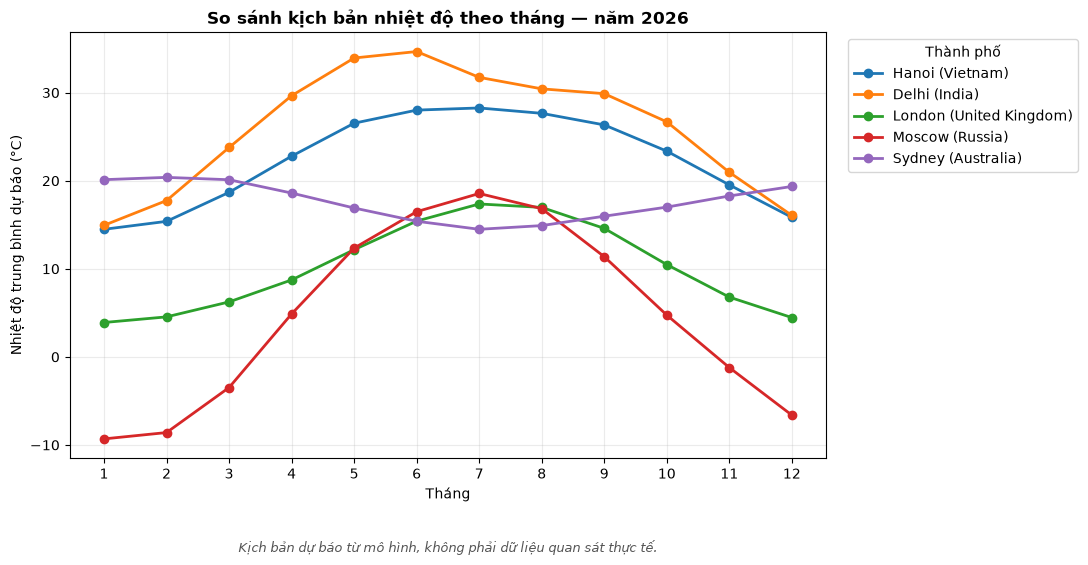

Đã lưu biểu đồ: reports\images\19_forecast_city_comparison_12_months.png


In [65]:
# Vẽ và lưu biểu đồ so sánh phục vụ báo cáo.
fig, ax = plt.subplots(figsize=(11, 5.8))
for city_label, group in FORECAST_CITY_COMPARISON.groupby('city_label', sort=False):
    ax.plot(
        group['month'], group['forecast_temperature_c'],
        marker='o', linewidth=2, label=city_label,
    )

ax.set_xticks(range(1, 13))
ax.set_xlabel('Tháng')
ax.set_ylabel('Nhiệt độ trung bình dự báo (°C)')
ax.set_title(f'So sánh kịch bản nhiệt độ theo tháng — năm {COMPARISON_FORECAST_YEAR}', fontweight='bold')
ax.grid(alpha=0.25)
ax.legend(title='Thành phố', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.text(
    0.5, -0.22,
    'Kịch bản dự báo từ mô hình, không phải dữ liệu quan sát thực tế.',
    transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='#555555',
)
plt.tight_layout()

comparison_image_path = REPORT_IMAGES_DIR / '19_forecast_city_comparison_12_months.png'
plt.savefig(comparison_image_path, dpi=160, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ:', comparison_image_path.relative_to(PROJECT_ROOT))


**Cách diễn giải biểu đồ:** so sánh cùng một năm và cùng 12 tháng giúp quan sát mức nhiệt nền, biên độ mùa vụ và sự lệch pha mùa giữa các thành phố. Chênh lệch trên biểu đồ không phải bằng chứng về nhiệt độ quan sát thực tế trong tương lai. Khi diễn giải, cần nhấn mạnh đây là kịch bản tham khảo; chỉ horizon 1–12 tháng có backtest lịch sử.


### 8.5. Lưu mô hình chính thức

#### 8.5.1. Lưu Pipeline chính thức

`model.pkl` chứa toàn bộ preprocessing và model đã refit trên train + validation.


In [66]:
FINAL_MODEL_PATH = MODELS_DIR / 'model.pkl'
FINAL_METADATA_PATH = MODELS_DIR / 'model_metadata.json'

joblib.dump(final_model, FINAL_MODEL_PATH)


['E:\\FPT\\HocKy3\\PROJECT_1\\PROJECT\\Global-Surface-Temperature-Analysis\\models\\model.pkl']

#### 8.5.2. Tạo metadata triển khai

Metadata ghi feature contract, metric, horizon và các artifact liên quan.


In [67]:
model_metadata = {
    'created_at': datetime.now(timezone.utc).isoformat(),
    'created_by': '06_machine_learning.ipynb',
    'model_type': best_model_name,
    'target': Y_COLUMN,
    'feature_names': FEATURE_NAMES,
    'numeric_feature_names': NUMERIC_FEATURES,
    'categorical_feature_names': CATEGORICAL_FEATURES,
    'preprocessing': 'Pipeline(ColumnTransformer(StandardScaler + OneHotEncoder))',
    'artifact_type': 'scikit_learn_pipeline',
    'scaler_required': False,
    'forecast_scenario': FEATURE_METADATA['forecast_scenario'],
    'forecast_horizon_months': FORECAST_HORIZON_MONTHS,
    'trained_on': 'train + validation (1863–1993)',
    'evaluated_on': 'test (1994–2013), một lần duy nhất',
    'metrics_validation': {
        'MAE': float(best_row['MAE (validation)']),
        'RMSE': float(best_row['RMSE (validation)']),
        'R2': float(best_row['R2 (validation)']),
    },
    'metrics_test': {key: float(value) for key, value in final_test_metrics.items()},
    'metrics_climatology_baseline_validation': {
        key: float(value) for key, value in baseline_validation_metrics.items()
    },
    'ablation_study_validation': ABLATION_RESULTS.to_dict(orient='records'),
    'rolling_origin_backtest': ROLLING_BACKTEST_SUMMARY.to_dict(orient='records'),
    'candidate_models_compared': list(results_df.index),
    'feature_engineering_metadata': str(METADATA_PATH.relative_to(PROJECT_ROOT)),
}


#### 8.5.3. Lưu metadata và ghi chú giới hạn

Ghi rõ giới hạn dữ liệu kết thúc năm 2013 để ứng dụng không diễn giải quá mức dự báo dài hạn.


In [68]:
model_metadata['notes'] = [
    'model.pkl đã chứa preprocessing; không dùng scaler.pkl bên ngoài Pipeline.',
    'Model chỉ dùng feature biết trước tại tháng mục tiêu; không dùng lag/rolling.',
    'Rolling-origin backtest đo horizon 1–12 tháng trong lịch sử.',
    'Dữ liệu huấn luyện kết thúc 2013-09; dự báo các năm sau là ngoại suy nhiệt độ kỳ vọng.',
    'Cần nạp và kiểm duyệt quan trắc mới trước khi tái huấn luyện để tăng độ tin cậy.',
]

with open(FINAL_METADATA_PATH, 'w', encoding='utf-8') as handle:
    json.dump(model_metadata, handle, ensure_ascii=False, indent=2)

print(f'Đã lưu mô hình: {FINAL_MODEL_PATH.relative_to(PROJECT_ROOT)}')
print(f'Đã lưu metadata: {FINAL_METADATA_PATH.relative_to(PROJECT_ROOT)}')
print('Preprocessing đã nằm trong model.pkl; không dùng scaler.pkl riêng.')


Đã lưu mô hình: models\model.pkl
Đã lưu metadata: models\model_metadata.json
Preprocessing đã nằm trong model.pkl; không dùng scaler.pkl riêng.


### 8.6. Xác thực lại mô hình đã lưu

Nạp lại `model.pkl` từ đĩa — độc lập với các biến đang có trong bộ nhớ — rồi so sánh dự đoán. File này đã bao gồm cả imputation, chuẩn hóa (với Linear Regression), one-hot `country_name` và model.

In [69]:
reloaded_model = joblib.load(FINAL_MODEL_PATH)
reload_input = X_test[X_ALL_COLUMNS].iloc[:1000]
reload_pred = reloaded_model.predict(reload_input)
original_pred_subset = final_test_pred[:1000]

matches = np.allclose(reload_pred, original_pred_subset, rtol=1e-5, atol=1e-5)
print(f'{"PASS" if matches else "FAIL"}: dự đoán từ model.pkl đã lưu khớp với mô hình vừa huấn luyện '
      f'(kiểm tra trên 1.000 dòng test).')
if not matches:
    raise RuntimeError('model.pkl vừa lưu cho kết quả khác mô hình gốc — không lưu đúng.')

PASS: dự đoán từ model.pkl đã lưu khớp với mô hình vừa huấn luyện (kiểm tra trên 1.000 dòng test).


## 9. Kết luận và bàn giao cho ứng dụng


### 9.1. Trả lời năm câu hỏi cốt lõi

### 9.1.1. Tóm tắt dữ liệu và model

In ngắn gọn trạng thái data contract, model được chọn và metric test chính thức.


In [70]:
print('1. Dữ liệu đã sẵn sàng huấn luyện?')
print(f'   Có. {len(df):,} dòng khớp metadata và không thiếu target/feature đầu vào.')
print(f'   Split thời gian: train {len(train_df):,} · validation {len(validation_df):,} · test {len(test_df):,}.')

print()
print('2. Model nào tốt nhất?')
print(f'   {best_model_name}: RMSE validation {best_row["RMSE (validation)"]:.4f} °C, '
      f'R² validation {best_row["R2 (validation)"]:.4f}.')
print(f'   Metric test chính thức: RMSE {final_test_metrics["RMSE"]:.4f} °C.')


1. Dữ liệu đã sẵn sàng huấn luyện?
   Có. 5,579,085 dòng khớp metadata và không thiếu target/feature đầu vào.
   Split thời gian: train 4,468,327 · validation 374,280 · test 736,478.

2. Model nào tốt nhất?
   Linear Regression: RMSE validation 1.2787 °C, R² validation 0.9839.
   Metric test chính thức: RMSE 1.3297 °C.


### 9.1.2. Giá trị feature, giới hạn và artifact

Kết luận phân biệt rõ backtest lịch sử với dự báo dài hạn ngoài phạm vi quan trắc.


1. Feature có giá trị tăng thêm?

- Có. Model được so sánh với climatology baseline; feature nổi bật của model cây: loc_month_climatology.

2. Kết quả có đáng tin cậy?

- Bias test -0.3847 °C. Độ tin cậy được giới hạn bởi dữ liệu chỉ đến 2013-09.

3. Artifact bàn giao cho ứng dụng

- Linear Regression được lưu tại models/model.pkl cùng models/model_metadata.json.

### 9.2. Bàn giao cho Notebook 07

**Notebook 07 / ứng dụng phải:**

- Nạp `models/model.pkl` bằng `joblib.load`.
- Đọc `feature_names`, `numeric_feature_names`, `categorical_feature_names` và horizon trong `models/model_metadata.json`; truyền DataFrame đúng tên cột vào `model.predict()` — Pipeline tự làm preprocessing.
- Tra cứu `country_name`, `latitude`, `longitude`, `is_major_city` và climatology của thành phố từ bảng/tệp thống kê đã được fit bằng dữ liệu training.
- Tự dựng các feature mùa vụ (`month_sin`, `month_cos`, ...), `years_since_start`, tương tác vĩ độ–mùa vụ từ năm/tháng người dùng chọn. Không yêu cầu người dùng nhập nhiệt độ lịch sử.
- Chỉ cho phép giao diện dự báo trong tối đa 12 tháng từ ngày hiện tại; luôn hiển thị đây là **ước lượng khí hậu kỳ vọng**, do dữ liệu huấn luyện kết thúc năm 2013.

### 9.3. Checklist hoàn thành Notebook 06

- [x] Đọc đúng bảng `public.city_temperature_features` và hợp đồng `feature_metadata.json` từ Notebook 05.
- [x] Kiểm tra kích thước, kiểu dữ liệu, số dòng theo từng split khớp metadata.
- [x] Xác định đúng 14 feature số, 1 feature phân loại (`country_name`) và 1 target theo hợp đồng Notebook 05.
- [x] Kiểm tra missing; Pipeline chỉ impute nội bộ khi cần để không làm hỏng dữ liệu thời gian.
- [x] Dùng đúng nhãn `data_split` có sẵn (chia theo thời gian), không chia lại ngẫu nhiên.
- [x] Huấn luyện Linear Regression, Random Forest, XGBoost trên cùng dữ liệu, cùng tập validation để so sánh.
- [x] So sánh bằng MAE/RMSE/R² với climatology baseline, có xét thêm khả năng tổng quát, thời gian huấn luyện, độ phức tạp triển khai.
- [x] Chọn một mô hình dựa trên số liệu thật, không phỏng đoán trước.
- [x] Backtest rolling-origin cho horizon 1–12 tháng và đánh giá mô hình được chọn trên test đúng một lần duy nhất.
- [x] Lưu Pipeline hoàn chỉnh `models/model.pkl` và `models/model_metadata.json`.
- [x] Xác thực lại mô hình đã lưu bằng cách nạp lại từ đĩa và so khớp dự đoán.